In [473]:
import ast
import math
import pickle
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots
from sklearn.metrics import matthews_corrcoef
from tqdm import tqdm

plt.style.use(['science', 'nature'])
plt.rcParams['figure.dpi'] = 300

In [474]:
project_root = "../../../.."

all_test_accessions = open(f"{project_root}/data/processed_data/genome_partitions/test_partition_accessions.txt").read().splitlines()
all_test_accessions = [accession for accession in all_test_accessions if accession not in ['GCF_000026105.1', 'GCF_900636915.1', 'GCF_900635955.1']]

# Load genome info from CSV and create dict for all test accessions
genome_info_df = pd.read_csv(f"{project_root}/data/processed_data/dataset_information/genomes_info_with_partitions.csv")
genome_info_df = genome_info_df.set_index('accession')

# Families that use translation table 4 (Mycoplasmataceae and related)
TT4_FAMILIES = ['Mycoplasmataceae']

all_genomes = {}
for acc in all_test_accessions:
    if acc in genome_info_df.index:
        row = genome_info_df.loc[acc]
        # Assign translation table based on family
        translation_table = 4 if row['family'] in TT4_FAMILIES else 11
        all_genomes[acc] = {
            'family': row['family'],
            'domain': row['domain'],
            'gc_content': row['gc_content'],
            'translation_table': translation_table
        }

# Create filtered accession lists by translation table
tt4_accessions = [acc for acc in all_test_accessions if acc in all_genomes and all_genomes[acc]['translation_table'] == 4]
tt11_accessions = [acc for acc in all_test_accessions if acc in all_genomes and all_genomes[acc]['translation_table'] == 11]

print(f"Translation Table 4 genomes: {len(tt4_accessions)}")
print(f"Translation Table 11 genomes: {len(tt11_accessions)}")

#"Reference" test accessions (1 per family)
genomes = {
    'GCF_000011125.1': {'translation_table': 11, 'gc_content': 56.3, 'domain': 'Archaea'},
    'GCF_000008665.1': {'translation_table': 11, 'gc_content': 48.6, 'domain': 'Archaea'},
    'GCF_004799605.1': {'translation_table': 11, 'gc_content': 66.3, 'domain': 'Archaea'},
    'GCF_000017165.1': {'translation_table': 11, 'gc_content': 31.3, 'domain': 'Archaea'},
    'GCF_000007345.1': {'translation_table': 11, 'gc_content': 42.7, 'domain': 'Archaea'},
    'GCF_000012545.1': {'translation_table': 11, 'gc_content': 27.6, 'domain': 'Archaea'},
    'GCF_000007365.1': {'translation_table': 11, 'gc_content': 25.3, 'domain': 'Bacteria'},
    'GCF_000009045.1': {'translation_table': 11, 'gc_content': 43.5, 'domain': 'Bacteria'},
    'GCF_025998455.1': {'translation_table': 11, 'gc_content': 38.5, 'domain': 'Bacteria'},
    'GCF_000195955.2': {'translation_table': 11, 'gc_content': 65.6, 'domain': 'Bacteria'},
    'GCF_020736045.1': {'translation_table': 11, 'gc_content': 38.2, 'domain': 'Bacteria'},
    'GCF_000012765.1': {'translation_table': 4, 'gc_content': 23.8, 'domain': 'Bacteria'},
    'GCF_028609885.1': {'translation_table': 11, 'gc_content': 61.4, 'domain': 'Bacteria'},
    'GCF_000005845.2': {'translation_table': 11, 'gc_content': 50.8, 'domain': 'Bacteria'},
    'GCF_000006765.1': {'translation_table': 11, 'gc_content': 66.6, 'domain': 'Bacteria'},
    'GCF_000013425.1': {'translation_table': 11, 'gc_content': 32.9, 'domain': 'Bacteria'}}

test_accessions = list(genomes.keys()) #List of the "reference" test accessions 

Translation Table 4 genomes: 3
Translation Table 11 genomes: 212


In [475]:
def get_full_cds(reads_dict):
    for read in reads_dict.keys():
        cds_fragments_connections = reads_dict[read]['cds_fragments_connection']
        cds_coords = reads_dict[read]['cds_coords']

        indices_to_remove = []
        
        for cds_frag_mapping in cds_fragments_connections:
            if len(cds_frag_mapping) > 1:
                # Postprocessing for testset due to how short fragments were removed
                if len(cds_fragments_connections) != cds_frag_mapping[0] + 1:
                    cds_frag_mapping = [cds_index - 1 for cds_index in cds_frag_mapping]
                
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [0, 2]:
                    cds_frag_mapping = [0, 1]
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [2, 3, 4]:
                    cds_frag_mapping = [0, 1, 2]
                
                start_cds_frag = cds_coords[min(cds_frag_mapping)][0]
                end_cds_frag = cds_coords[max(cds_frag_mapping)][1]

                indices_to_remove += cds_frag_mapping
                
                # Add the new disrupted fragment
                cds_coords.append([start_cds_frag, end_cds_frag, 'disrupted_rf'])
                
                # Update the dictionary
                reads_dict[read]['cds_coords'] = cds_coords

        # Remove the indices in reverse order to avoid index shifting issues
        for index in sorted(indices_to_remove, reverse=True):
            cds_coords.pop(index)
    
    return reads_dict

In [476]:
def load_in_processed_datasets(test_accession, data_type, project_root=project_root):
    #Load in testset data
    with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/testset_dict.pkl", "rb") as testset_dict_file:
        testset_dict = pickle.load(testset_dict_file)

    with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/read_names_list.pkl", "rb") as read_names_list_file:
        read_names_list = pickle.load(read_names_list_file)

    #Load on prodigal preds
    with open(f"{project_root}/data/processed_data/predictions/processed_predictions/prodigal_preds/{data_type}/{test_accession}/model_preds_dict.pkl", "rb") as preds_prodigal_dict_file:
        preds_prodigal = pickle.load(preds_prodigal_dict_file)

    #Load in FGS predictions
    with open(f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{data_type}/{test_accession}.pkl", "rb") as preds_fgs_dict_file:
        preds_fgs_complete = pickle.load(preds_fgs_dict_file)

    #Load in Model preds
    with open(f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS_A1/model_without_errors/{data_type}/esm2_8m_all_genomes_seed_42_trained_final/{test_accession}/model_preds_dict.pkl", "rb") as model_preds_dict_file:
        preds_deep_cds_a1 = pickle.load(model_preds_dict_file) 

    with open(f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_without_errors/{data_type}/full_model_all_genomes_seed_42_trained_final/{test_accession}/model_preds_dict.pkl", "rb") as model_preds_dict_file:
        preds_deep_cds = pickle.load(model_preds_dict_file)

        
    return read_names_list, get_full_cds(testset_dict), get_full_cds(preds_prodigal), \
        get_full_cds(preds_fgs_complete), get_full_cds(preds_deep_cds_a1), \
        get_full_cds(preds_deep_cds)
        
    

In [477]:
def calculate_iou(coord1, coord2):
    """
    Calculate Intersection over Union (IoU) for two gene coordinates.
    Each coord (coord1 and coord2, respectively) is a tuple: (cds_start, cds_stop, reading_frame)
    Only compares genes in the same reading frame.
    
    Returns:
      iou: IoU value between 0 and 1, or 0 if different reading frames.
    """

    start1, stop1, rf1 = coord1
    start2, stop2, rf2 = coord2
    
    #Only compare genes in the same reading frame
    if rf1 != rf2:
        return 0.0
    
    #Calculate intersection
    intersection_start = max(start1, start2)
    intersection_stop = min(stop1, stop2)
    
    #No intersection if start > stop
    if intersection_start >= intersection_stop:
        return 0.0
    
    intersection_length = intersection_stop - intersection_start
    
    #Calculate union
    union_start = min(start1, start2)
    union_stop = max(stop1, stop2)
    union_length = union_stop - union_start
    
    #Calculate IoU
    iou = intersection_length / union_length if union_length > 0 else 0.0
    
    return iou

In [478]:
def find_matching_genes(predicted_coords, actual_coords, overlap_criteria):
    """
    Find matching genes based on IoU overlap criteria.

    Args:
        predicted_coords (list): List of predicted gene coordinates (tuples).
        actual_coords (list): List of actual gene coordinates (tuples).
        overlap_criteria (float): Minimum IoU required to consider a match.
    
    Returns:
        matched_pairs: list of (pred_idx, actual_idx) pairs that match
        len(matched_paires) = tp_count: number of true positives
    """

    #Initialize
    matched_pairs = []
    used_actual = set()  #Track which actual genes have been matched
    used_predicted = set()  #Track which predicted genes have been matched
    
    #For each predicted gene, find the best matching actual gene
    for pred_idx, pred_coord in enumerate(predicted_coords):
        best_iou = 0.0
        best_actual_idx = -1
        
        for actual_idx, actual_coord in enumerate(actual_coords):
            #Skip if this actual gene is already matched
            if actual_idx in used_actual:
                continue
                
            iou = calculate_iou(pred_coord, actual_coord)
            
            #Check if this is better than current best and meets criteria
            if iou >= overlap_criteria and iou > best_iou:
                best_iou = iou
                best_actual_idx = actual_idx
        
        #If we found a valid match
        if best_actual_idx != -1:
            matched_pairs.append((pred_idx, best_actual_idx))
            used_actual.add(best_actual_idx)
            used_predicted.add(pred_idx)

    
    return matched_pairs, len(matched_pairs)


In [479]:
def calculate_metrics(testset_dict, model_preds_dict, all_test_read_names, overlap_criteria):
    """
    Calculate sensitivity, precision, and F1-score for given overlap criteria.
    Overlap is based on IoU (Intersection over Union).
    
    Precision (PPV): The ratio of true positives to all predicted genes; TP / (TP + FP)
    Sensitivity (Recall): The ratio of true positives to all actual genes; TP / (TP + FN)
    F1-score: Harmonic mean of precision and sensitivity; 2 * (precision * sensitivity) / (precision + sensitivity)
    
    Args:
        testset_dict: Dictionary containing ground truth CDS coordinates
        model_preds_dict: Dictionary containing predicted CDS coordinates
        all_test_read_names: List of all read names to evaluate
        overlap_criteria: Minimum IoU threshold for considering a match (0.0< to 1.0)
    
    Returns:
        results: Dictionary containing calculated metrics
    """
    
    #Initialize
    total_tp = 0
    total_predicted_genes = 0
    total_actual_genes = 0
    
    #Iterate through each read
    for read_name in all_test_read_names:

        #Get coordinates for this read; both for test set and model predictions
        cds_coords_testset = []
        cds_coords_model = []
        
        if read_name in testset_dict:
            cds_coords_testset = testset_dict[read_name].get("cds_coords", [])
        
        if read_name in model_preds_dict:
            cds_coords_model = model_preds_dict[read_name].get("cds_coords", [])
        
        #Count genes for this read
        num_predicted = len(cds_coords_model) #predicted gene fragments
        num_actual = len(cds_coords_testset)  #actual gene fragments

        #Find matching genes based on overlap criteria
        _, tp_count = find_matching_genes(cds_coords_model, cds_coords_testset, overlap_criteria)

        #Update counts
        total_predicted_genes += num_predicted
        total_actual_genes += num_actual
        total_tp += tp_count
    
    #Calculate overall metrics
    total_fp = total_predicted_genes - total_tp
    total_fn = total_actual_genes - total_tp
    
    #Calculate precision
    precision = total_tp / total_predicted_genes if total_predicted_genes > 0 else 0.0
    
    #Calculate recall/sensitivity
    recall = total_tp / total_actual_genes if total_actual_genes > 0 else 0.0
    
    #Calculate F1-score (harmonic mean of precision and recall)
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    #Store results
    results = {
        'overlap_criteria': overlap_criteria,
        'total_predicted_genes': total_predicted_genes,
        'total_actual_genes': total_actual_genes,
        'total_true_positives': total_tp,
        'total_false_positives': total_fp,
        'total_false_negatives': total_fn,
        'precision': round(precision, 3),
        'recall': round(recall, 3),
        'f1_score': round(f1_score, 3)
    }
    
    return results

In [480]:
def get_metric_for_models(performance_metric, performance_metrics_genomes_dict):
    """ 
    Get performance metric for all models across genomes in a easy-to-plot dictionary format.

    Args:
        performance_metric (str): The performance metric to extract (e.g., 'precision', 'recall', 'f1_score').
        performance_metrics_genomes_dict (dict): A dictionary containing performance metrics for each genome and model.
    
    Returns:
        performance_metric_dict (dict): A dictionary with lists of the specified performance metric for each model and genome accession.
    """
    #Initialize
    performance_metric_dict = dict()
    performance_metric_dict["prodigal"] = []
    performance_metric_dict["fgs_complete"] = []
    performance_metric_dict["deep_cds"] = []
    performance_metric_dict["deep_cds_a1"] = []
    performance_metric_dict["genome_accession"] = []

    #Extract metric for each genome and model
    for genome_accession in performance_metrics_genomes_dict.keys():
        performance_metric_dict["prodigal"].append(performance_metrics_genomes_dict[genome_accession]["prodigal"][performance_metric])
        performance_metric_dict["fgs_complete"].append(performance_metrics_genomes_dict[genome_accession]["fgs_complete"][performance_metric])
        performance_metric_dict["deep_cds"].append(performance_metrics_genomes_dict[genome_accession]["deep_cds"][performance_metric])
        performance_metric_dict["deep_cds_a1"].append(performance_metrics_genomes_dict[genome_accession]["deep_cds_a1"][performance_metric])
        performance_metric_dict["genome_accession"].append(genome_accession)

    # Extract data
    genome_accessions = performance_metric_dict['genome_accession']
    prodigal_scores = performance_metric_dict['prodigal']
    fgs_scores = performance_metric_dict['fgs_complete']
    deep_cds_scores = performance_metric_dict['deep_cds']
    deep_cds_a1_scores = performance_metric_dict['deep_cds_a1']

    return genome_accessions, prodigal_scores, fgs_scores, deep_cds_scores, deep_cds_a1_scores

In [481]:
def get_metric_for_models(performance_metric, performance_metrics_genomes_dict):
    """
    Get performance metric for all models across genomes in a easy-to-plot dictionary format.
    
    Args:
        performance_metric (str): The performance metric to extract (e.g., 'precision', 'recall', 'f1_score').
        performance_metrics_genomes_dict (dict): A dictionary containing performance metrics for each genome and model.
    
    Returns:
        dict: A dictionary with genome accessions and model scores
    """
    if not performance_metrics_genomes_dict:
        return {}
    
    # Get model names from the first genome entry
    first_genome = next(iter(performance_metrics_genomes_dict.values()))
    model_names = [key for key in first_genome.keys()]
    
    # Initialize result dictionary
    result_dict = {"genome_accession": []}
    for model_name in model_names:
        result_dict[model_name] = []
    
    # Extract metric for each genome and model
    for genome_accession, models_data in performance_metrics_genomes_dict.items():
        result_dict["genome_accession"].append(genome_accession)
        
        for model_name in model_names:
            if model_name in models_data and performance_metric in models_data[model_name]:
                result_dict[model_name].append(models_data[model_name][performance_metric])
            else:
                result_dict[model_name].append(None)  # Handle missing data
    
    return result_dict

In [482]:
def plot_metric_per_genome_bars(metric_data, metric_name, data_type, model_display_names=None, colors=None, genome_metadata=None):
    """
    Plot specified performance metric across different genomes and models using bar charts.
    
    Args:
        metric_data (dict): Dictionary containing genome accessions and model scores
        metric_name (str): Name of the performance metric to display on the y-axis
        model_display_names (dict, optional): Dictionary mapping model names to display names
        colors (list, optional): List of colors for the bars. If None, default colors will be used
        genome_metadata (dict, optional): Dictionary with genome metadata (translation_table, gc_content, domain)
    """
    genome_accessions = metric_data["genome_accession"]
    model_names = [key for key in metric_data.keys() if key != "genome_accession"]
    
    if not model_names:
        print("No model data found!")
        return
    
    # Create extended x-axis labels with metadata
    if genome_metadata is not None:
        x_labels = []
        for acc in genome_accessions:
            if acc in genome_metadata:
                meta = genome_metadata[acc]
                tt = meta.get('translation_table', 'N/A')
                gc = meta.get('gc_content', 'N/A')
                domain = meta.get('domain', 'N/A')[0]  # First letter (B/A)
                label = f"{acc}\n(TT:{tt}, GC:{gc}\\%, {domain})"
            else:
                label = acc
            x_labels.append(label)
    else:
        x_labels = genome_accessions
    
    # Set up display names
    if model_display_names is None:
        display_names = {name: name for name in model_names}
    else:
        display_names = model_display_names
    
    # Set up colors
    if colors is None:
        default_colors = ['skyblue', 'lightgreen', 'orchid', 'coral', 'gold', 'lightgray', 'pink', 'lightcyan']
        colors = default_colors[:len(model_names)]
    
    # Create x positions for the bars
    x = np.arange(len(genome_accessions))
    n_models = len(model_names)
    width = 0.9 / n_models  # Adjust width based on number of models
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(max(13, len(genome_accessions) * 1.5), 7))
    
    bars_list = []
    # Create bars for each model
    for i, model_name in enumerate(model_names):
        scores = metric_data[model_name]
        # Filter out None values for plotting
        valid_scores = [score if score is not None else 0 for score in scores]
        
        x_pos = x - (n_models - 1) * width / 2 + i * width
        bars = ax.bar(x_pos, valid_scores, width, 
                     label=display_names.get(model_name, model_name), 
                     alpha=0.8, color=colors[i % len(colors)])
        bars_list.append(bars)
    
    # Customize the plot
    ax.set_ylabel(metric_name.replace("_", "-"), fontsize=16)
    ax.set_title(f'{metric_name.replace("_", "-")} Across Models and Genomes in Test Set (Overall CDS-level) \n {data_type.capitalize().replace("_", " ")}', fontsize=18, fontweight='normal')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=11)
    ax.tick_params(axis='y', labelsize=12)
    
    # Legend: single row, positioned below x-axis labels to avoid overlap
    ax.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=len(model_names), fontsize=12)
    
    # Add value labels on bars
    def add_value_labels(bars, scores):
        for bar, score in zip(bars, scores):
            if score is not None:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                       f'{height:.3f}', ha='center', va='bottom', fontsize=11)
    
    for bars, model_name in zip(bars_list, model_names):
        add_value_labels(bars, metric_data[model_name])
    
    # Set y-axis limits for better visualization (you can adjust these)
    ax.set_ylim(0, 1.05)
    
    # Tighten x-axis margins to reduce empty space on sides
    ax.set_xlim(-0.5, len(genome_accessions) - 0.5)
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, axis='y')
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    # Display the plot
    plt.show()

In [483]:
def plot_all_models_comparison(performance_metric, performance_metrics_genomes_dict, data_type, genome_metadata=None):
    """
    Convenience function to extract data and plot all models for a given metric.
    
    Args:
        performance_metric (str): The performance metric to plot
        performance_metrics_genomes_dict (dict): Performance metrics dictionary
        data_type (str): Data type description for the plot title
        genome_metadata (dict, optional): Dictionary with genome metadata for extended x-axis labels
    """
    # Extract the data
    metric_data = get_metric_for_models(performance_metric, performance_metrics_genomes_dict)
    
    # Optional: Define custom display names for better labels
    model_display_names = {
        "prodigal": "MetaProdigal",
        "fgs_complete": "FGS",
        "deep_cds_a1": "DeepCDS (A1)",
        "deep_cds": "DeepCDS (Full)"
    }
    
    # Optional: Define custom colors
    custom_colors = ['skyblue', 'orange', 'orchid', 'forestgreen', 'purple']
    custom_colors = custom_colors[0:len(list(model_display_names.keys()))+1]
    
    # Plot the data
    plot_metric_per_genome_bars(metric_data, performance_metric.title(), data_type,
                               model_display_names, custom_colors, genome_metadata)

In [484]:
def find_wrong_predictions(testset_dict, model_preds_dict, all_test_read_names, overlap_criteria):
    """
    Find reads with wrong predictions (false positives or false negatives).
    
    Args:
        testset_dict: Dictionary containing ground truth CDS coordinates
        model_preds_dict: Dictionary containing predicted CDS coordinates
        all_test_read_names: List of all read names to evaluate
        overlap_criteria: Minimum IoU threshold for considering a match
    
    Returns:
        wrong_predictions: Dictionary with details about wrong predictions per read
    """
    wrong_predictions = {
        'reads_with_fp': [],  # Reads with false positives
        'reads_with_fn': [],  # Reads with false negatives
        'all_errors': [],     # All reads with any error
        'detailed_errors': {} # Detailed info per read
    }
    
    for read_name in all_test_read_names:
        # Get coordinates for this read
        cds_coords_testset = []
        cds_coords_model = []
        
        if read_name in testset_dict:
            cds_coords_testset = testset_dict[read_name].get("cds_coords", [])
        
        if read_name in model_preds_dict:
            cds_coords_model = model_preds_dict[read_name].get("cds_coords", [])
        
        num_predicted = len(cds_coords_model)
        num_actual = len(cds_coords_testset)
        
        # Find matching genes
        matched_pairs, tp_count = find_matching_genes(cds_coords_model, cds_coords_testset, overlap_criteria)
        
        # Calculate FP and FN for this read
        fp_count = num_predicted - tp_count
        fn_count = num_actual - tp_count
        
        has_error = fp_count > 0 or fn_count > 0
        
        if has_error:
            # Get indices of matched predictions and actuals
            matched_pred_indices = {pair[0] for pair in matched_pairs}
            matched_actual_indices = {pair[1] for pair in matched_pairs}
            
            # Find unmatched predictions (false positives)
            fp_coords = [cds_coords_model[i] for i in range(num_predicted) if i not in matched_pred_indices]
            
            # Find unmatched actuals (false negatives)
            fn_coords = [cds_coords_testset[i] for i in range(num_actual) if i not in matched_actual_indices]
            
            wrong_predictions['detailed_errors'][read_name] = {
                'predicted_coords': cds_coords_model,
                'actual_coords': cds_coords_testset,
                'matched_pairs': matched_pairs,
                'false_positive_coords': fp_coords,
                'false_negative_coords': fn_coords,
                'fp_count': fp_count,
                'fn_count': fn_count
            }
            
            wrong_predictions['all_errors'].append(read_name)
            
            if fp_count > 0:
                wrong_predictions['reads_with_fp'].append(read_name)
            if fn_count > 0:
                wrong_predictions['reads_with_fn'].append(read_name)
    
    # Summary statistics
    wrong_predictions['summary'] = {
        'total_reads': len(all_test_read_names),
        'reads_with_errors': len(wrong_predictions['all_errors']),
        'reads_with_fp': len(wrong_predictions['reads_with_fp']),
        'reads_with_fn': len(wrong_predictions['reads_with_fn']),
        'error_rate': len(wrong_predictions['all_errors']) / len(all_test_read_names) if all_test_read_names else 0
    }
    
    return wrong_predictions

# Main

In [485]:
data_types = ["without_errors_300bp"]

# Plot performance on overall reference test organisms

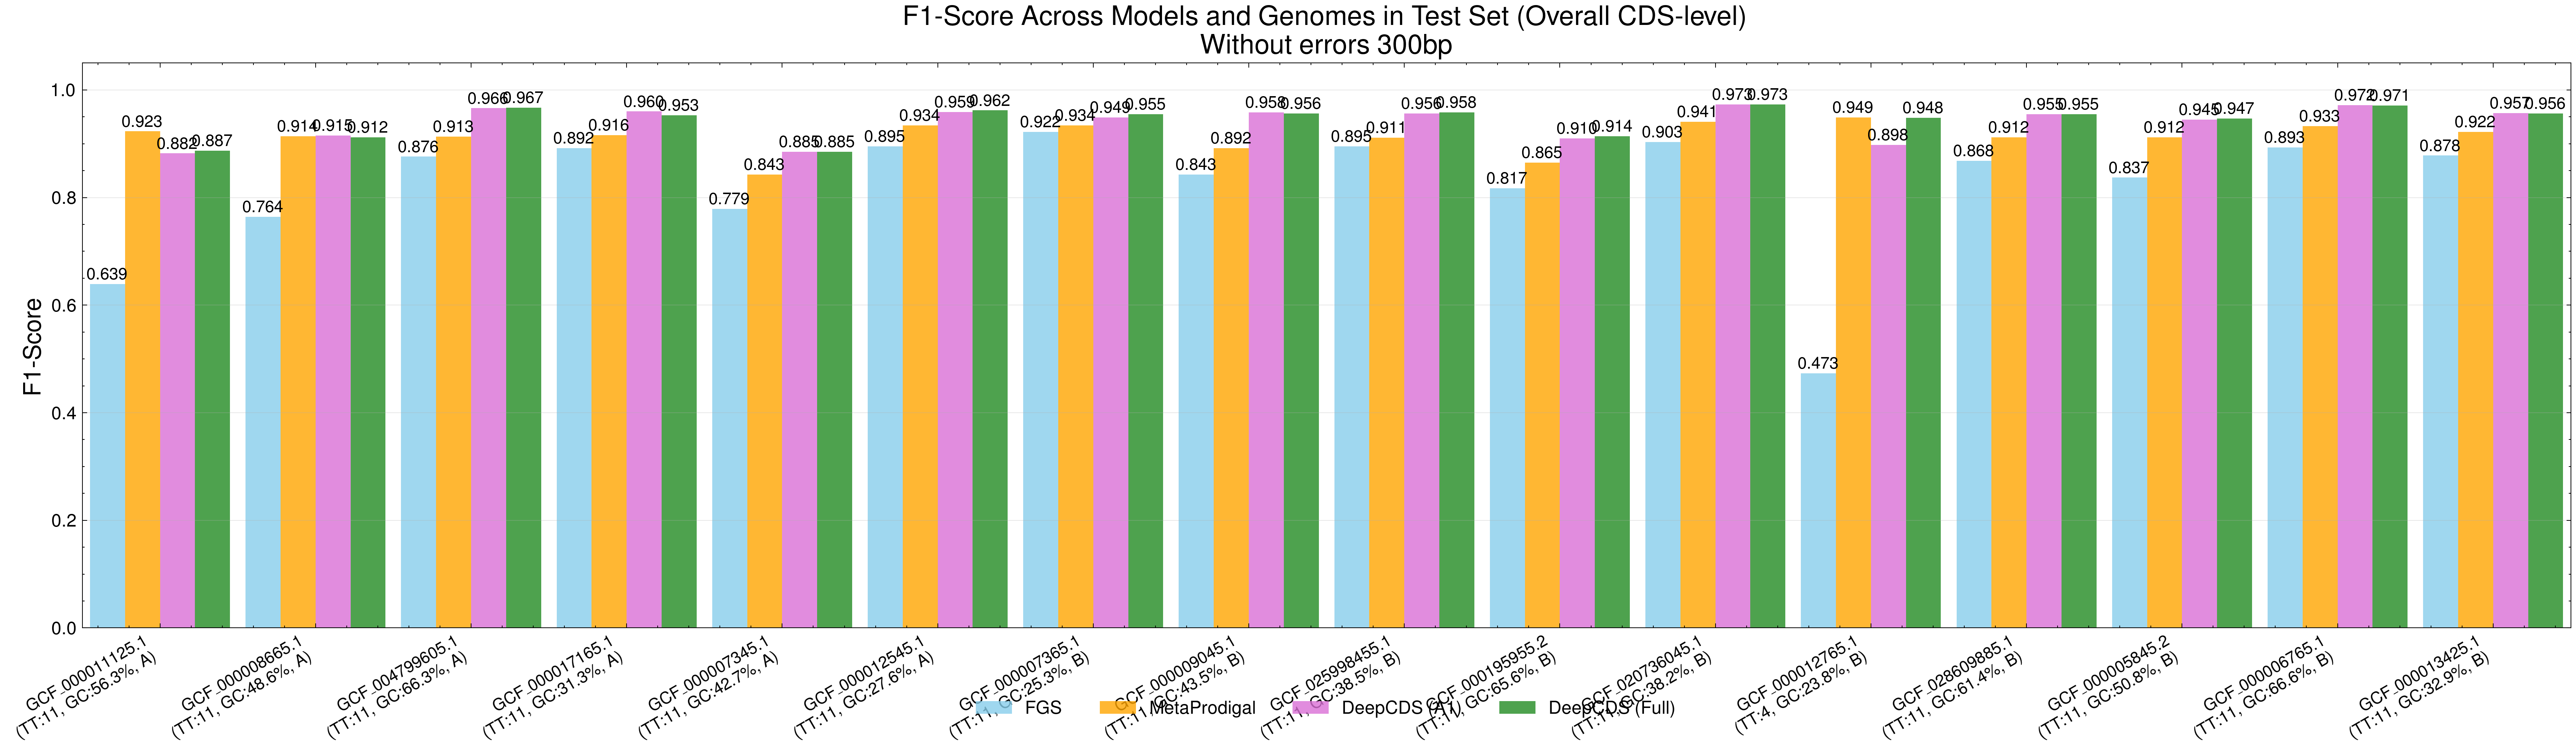

In [486]:
for data_type in data_types:

    #Initialize
    performance_metrics_genomes_dict = {}
    overlap_criteria = 1 #Overlap required to be considered a TP

    for test_accession in test_accessions:
        read_names_list, testset_dict, prodigal_dict, \
        preds_fgs_dict, preds_a1, \
        preds_deep_cds = load_in_processed_datasets(test_accession, data_type)

        #Store performance metrics for this genome
        performance_metrics_genomes_dict[test_accession] = {
            "fgs_complete": calculate_metrics(testset_dict, preds_fgs_dict, read_names_list, overlap_criteria),
            "prodigal": calculate_metrics(testset_dict, prodigal_dict, read_names_list, overlap_criteria),
            "deep_cds_a1": calculate_metrics(testset_dict, preds_a1, read_names_list, overlap_criteria),
            "deep_cds": calculate_metrics(testset_dict, preds_deep_cds, read_names_list, overlap_criteria)}
    
    #assess wrong predictions to find out if there are any patterns that raise concern/should be fixed
    wrong_predictions = find_wrong_predictions(testset_dict, preds_deep_cds, read_names_list, overlap_criteria)
        
    plot_all_models_comparison('f1_score', performance_metrics_genomes_dict, data_type, genomes)
    #plot_all_models_comparison('recall', performance_metrics_genomes_dict, data_type, genomes)
    #plot_all_models_comparison('precision', performance_metrics_genomes_dict, data_type, genomes)

In [487]:
wrong_predictions

{'reads_with_fp': ['GCF_000013425.1_simulated_reads_template5829',
  'GCF_000013425.1_simulated_reads_complement88',
  'GCF_000013425.1_simulated_reads_complement9113',
  'GCF_000013425.1_simulated_reads_complement9159',
  'GCF_000013425.1_simulated_reads_template8515',
  'GCF_000013425.1_simulated_reads_template4149',
  'GCF_000013425.1_simulated_reads_complement4797',
  'GCF_000013425.1_simulated_reads_template8158',
  'GCF_000013425.1_simulated_reads_complement4624',
  'GCF_000013425.1_simulated_reads_complement7291',
  'GCF_000013425.1_simulated_reads_template717',
  'GCF_000013425.1_simulated_reads_complement8904',
  'GCF_000013425.1_simulated_reads_complement2983',
  'GCF_000013425.1_simulated_reads_complement5110',
  'GCF_000013425.1_simulated_reads_complement4887',
  'GCF_000013425.1_simulated_reads_template4058',
  'GCF_000013425.1_simulated_reads_template8940',
  'GCF_000013425.1_simulated_reads_complement2395',
  'GCF_000013425.1_simulated_reads_complement4033',
  'GCF_00001

# Plot performance as a function of GC-content

In [488]:
def plot_metric_by_gc_content_boxplot(performance_metrics_dict, genome_metadata, metric_name, data_type,
                                       gc_bins=None, model_display_names=None, colors=None):
    """
    Plot boxplot of performance metric grouped by GC-content ranges.
    
    Args:
        performance_metrics_dict (dict): Dictionary with genome accessions as keys and model metrics as values
        genome_metadata (dict): Dictionary with genome metadata including gc_content
        metric_name (str): Name of the metric to plot (e.g., 'f1_score', 'precision', 'recall')
        data_type (str): Data type description for the plot title
        gc_bins (list, optional): List of bin edges for GC-content. Default: [0, 40, 50, 60, 100]
        model_display_names (dict, optional): Dictionary mapping model names to display names
        colors (list, optional): List of colors for each model
    """
    if gc_bins is None:
        gc_bins = [0, 40, 50, 60, 100]
    
    # Get model names from the first genome entry
    first_genome = next(iter(performance_metrics_dict.values()))
    model_names = list(first_genome.keys())
    
    # Set up display names
    if model_display_names is None:
        display_names = {name: name for name in model_names}
    else:
        display_names = model_display_names
    
    # Set up colors
    if colors is None:
        colors = ['skyblue', 'orange', 'orchid', 'forestgreen', 'purple']
    
    # Create bin labels
    bin_labels = []
    for i in range(len(gc_bins) - 1):
        if gc_bins[i] == 0:
            bin_labels.append(rf"$<${gc_bins[i+1]}\%")
        elif gc_bins[i+1] == 100:
            bin_labels.append(rf"$>${gc_bins[i]}\%")
        else:
            bin_labels.append(rf"{gc_bins[i]}--{gc_bins[i+1]}\%")
    
    # Organize data by GC bin and model
    data_by_bin_and_model = {label: {model: [] for model in model_names} for label in bin_labels}
    
    for acc, metrics in performance_metrics_dict.items():
        if acc not in genome_metadata:
            continue
        
        gc = genome_metadata[acc]['gc_content']
        
        # Find the appropriate bin
        bin_label = None
        for i in range(len(gc_bins) - 1):
            if gc_bins[i] <= gc < gc_bins[i + 1]:
                bin_label = bin_labels[i]
                break
        
        if bin_label is None:
            continue
        
        # Add metric values for each model
        for model in model_names:
            if model in metrics and metric_name in metrics[model]:
                data_by_bin_and_model[bin_label][model].append(metrics[model][metric_name])
    
    # Prepare data for boxplot
    n_models = len(model_names)
    n_bins = len(bin_labels)
    
    fig, ax = plt.subplots(figsize=(max(12, n_bins * 2), 7))
    
    # Position parameters
    width = 0.8 / n_models
    positions_base = np.arange(n_bins)
    
    # Create boxplots for each model
    for i, model in enumerate(model_names):
        positions = positions_base + (i - (n_models - 1) / 2) * width
        data = [data_by_bin_and_model[label][model] for label in bin_labels]
        
        bp = ax.boxplot(data, positions=positions, widths=width * 0.8,
                       patch_artist=True, manage_ticks=False)
        
        # Style the boxplot
        for patch in bp['boxes']:
            patch.set_facecolor(colors[i % len(colors)])
            patch.set_alpha(0.7)
        for median in bp['medians']:
            median.set_color('black')
    
    # Customize the plot
    ax.set_xlabel('GC-content Range', fontsize=12)
    ax.set_ylabel(metric_name.replace("_", " ").title(), fontsize=12)
    ax.set_title(f'{metric_name.replace("_", " ").title()} by GC-content Range\n{data_type}', fontsize=14)
    ax.set_xticks(positions_base)
    ax.set_xticklabels(bin_labels)
    
    # Add legend
    legend_patches = [plt.Rectangle((0, 0), 1, 1, facecolor=colors[i % len(colors)], alpha=0.7) 
                     for i in range(n_models)]
    ax.legend(legend_patches, [display_names.get(m, m) for m in model_names],
             bbox_to_anchor=(0.5, -0.12), loc='upper center', ncol=min(4, n_models))
    
    # Add grid
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0.0, 1.05)
    
    # Add count annotations above each bin
    for i, label in enumerate(bin_labels):
        count = len(data_by_bin_and_model[label][model_names[0]])
        ax.text(i, 1.02, f'n={count}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

In [489]:
from scipy import stats

def plot_metric_by_gc_content_sina(performance_metrics_dict, genome_metadata, metric_name, data_type,
                                   gc_bins=None, model_display_names=None, colors=None, 
                                   overlay='none'):
    """
    Plot sina plot of performance metric grouped by GC-content ranges.
    Sina plots show individual points jittered by local density.
    
    Args:
        performance_metrics_dict (dict): Dictionary with genome accessions as keys and model metrics as values
        genome_metadata (dict): Dictionary with genome metadata including gc_content
        metric_name (str): Name of the metric to plot (e.g., 'f1_score', 'precision', 'recall')
        data_type (str): Data type description for the plot title
        gc_bins (list, optional): List of bin edges for GC-content. Default: [0, 40, 50, 60, 100]
        model_display_names (dict, optional): Dictionary mapping model names to display names
        colors (list, optional): List of colors for each model
        overlay (str): Type of overlay - 'none', 'boxplot', or 'violin'. Default: 'none'
    """
    if gc_bins is None:
        gc_bins = [0, 40, 50, 60, 100]
    
    # Get model names from the first genome entry
    first_genome = next(iter(performance_metrics_dict.values()))
    model_names = list(first_genome.keys())
    
    # Set up display names
    if model_display_names is None:
        display_names = {name: name for name in model_names}
    else:
        display_names = model_display_names
    
    # Set up colors
    if colors is None:
        colors = ['orange', 'skyblue', 'orchid', 'forestgreen', 'purple']
    
    # Create bin labels
    bin_labels = []
    for i in range(len(gc_bins) - 1):
        if gc_bins[i] == 0:
            bin_labels.append(rf"$<${gc_bins[i+1]}\%")
        elif gc_bins[i+1] == 100:
            bin_labels.append(rf"$>${gc_bins[i]}\%")
        else:
            bin_labels.append(rf"{gc_bins[i]}--{gc_bins[i+1]}\%")
    
    # Organize data by GC bin and model
    data_by_bin_and_model = {label: {model: [] for model in model_names} for label in bin_labels}
    
    for acc, metrics in performance_metrics_dict.items():
        if acc not in genome_metadata:
            continue
        
        gc = genome_metadata[acc]['gc_content']
        
        # Find the appropriate bin
        bin_label = None
        for i in range(len(gc_bins) - 1):
            if gc_bins[i] <= gc < gc_bins[i + 1]:
                bin_label = bin_labels[i]
                break
        
        if bin_label is None:
            continue
        
        # Add metric values for each model
        for model in model_names:
            if model in metrics and metric_name in metrics[model]:
                data_by_bin_and_model[bin_label][model].append(metrics[model][metric_name])
    
    # Create the plot
    n_models = len(model_names)
    n_bins = len(bin_labels)
    
    fig, ax = plt.subplots(figsize=(max(12, n_bins * 2), 7))
    
    # Position parameters
    width = 0.8 / n_models
    positions_base = np.arange(n_bins)
    
    def sina_jitter(values, max_width=0.4):
        """Calculate jitter based on local density using KDE."""
        if len(values) < 2:
            return np.zeros(len(values))
        
        values = np.array(values)
        try:
            kde = stats.gaussian_kde(values)
            densities = kde(values)
            # Normalize densities to [0, 1]
            densities = densities / densities.max()
            # Random jitter scaled by density
            jitter = np.random.uniform(-1, 1, len(values)) * densities * max_width
        except:
            # Fallback to simple random jitter if KDE fails
            jitter = np.random.uniform(-max_width, max_width, len(values))
        
        return jitter
    
    # Plot for each model
    for i, model in enumerate(model_names):
        base_pos = positions_base + (i - (n_models - 1) / 2) * width
        
        for j, label in enumerate(bin_labels):
            values = data_by_bin_and_model[label][model]
            if not values:
                continue
            
            values = np.array(values)
            jitter = sina_jitter(values, max_width=width * 0.4)
            x_positions = base_pos[j] + jitter
            
            # Plot individual points
            ax.scatter(x_positions, values, 
                      c=colors[i % len(colors)], 
                      alpha=0.6, s=30, edgecolors='white', linewidth=0.5,
                      label=display_names.get(model, model) if j == 0 else "")
        
        # Add overlay based on type
        data = [data_by_bin_and_model[label][model] for label in bin_labels]
        
        if overlay == 'boxplot':
            bp = ax.boxplot(data, positions=base_pos, widths=width * 0.6,
                           patch_artist=True, manage_ticks=False, showfliers=False)
            
            for patch in bp['boxes']:
                patch.set_facecolor('none')
                patch.set_edgecolor(colors[i % len(colors)])
                patch.set_linewidth(1.5)
            for median in bp['medians']:
                median.set_color(colors[i % len(colors)])
                median.set_linewidth(2)
            for whisker in bp['whiskers']:
                whisker.set_color(colors[i % len(colors)])
                whisker.set_linewidth(1.5)
            for cap in bp['caps']:
                cap.set_color(colors[i % len(colors)])
                cap.set_linewidth(1.5)
        
        elif overlay == 'violin':
            # Only create violin for bins with enough data
            valid_data = []
            valid_positions = []
            for j, d in enumerate(data):
                if len(d) >= 2:  # Need at least 2 points for violin
                    valid_data.append(d)
                    valid_positions.append(base_pos[j])
            
            if valid_data:
                parts = ax.violinplot(valid_data, positions=valid_positions, 
                                     widths=width * 0.8, showmeans=False, 
                                     showmedians=True, showextrema=False)
                
                for pc in parts['bodies']:
                    pc.set_facecolor(colors[i % len(colors)])
                    pc.set_alpha(0.3)
                    pc.set_edgecolor(colors[i % len(colors)])
                    pc.set_linewidth(1.5)
                
                parts['cmedians'].set_color(colors[i % len(colors)])
                parts['cmedians'].set_linewidth(2)
    
    # Customize the plot
    ax.set_xlabel('GC-content Range', fontsize=12)
    ax.set_ylabel(metric_name.replace("_", " ").title(), fontsize=12)
    ax.set_title(f'{metric_name.replace("_", " ").title()} by GC-content Range (Sina Plot)\n{data_type}', fontsize=14)
    ax.set_xticks(positions_base)
    ax.set_xticklabels(bin_labels)
    
    # Add legend (remove duplicates)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(),
             bbox_to_anchor=(0.5, -0.12), loc='upper center', ncol=min(4, n_models))
    
    # Add grid
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0.0, 1.05)
    
    # Add count annotations
    for i, label in enumerate(bin_labels):
        count = len(data_by_bin_and_model[label][model_names[0]])
        ax.text(i, 1.02, f'n={count}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

Processing without_errors_300bp: 100%|██████████| 215/215 [00:43<00:00,  4.97it/s]


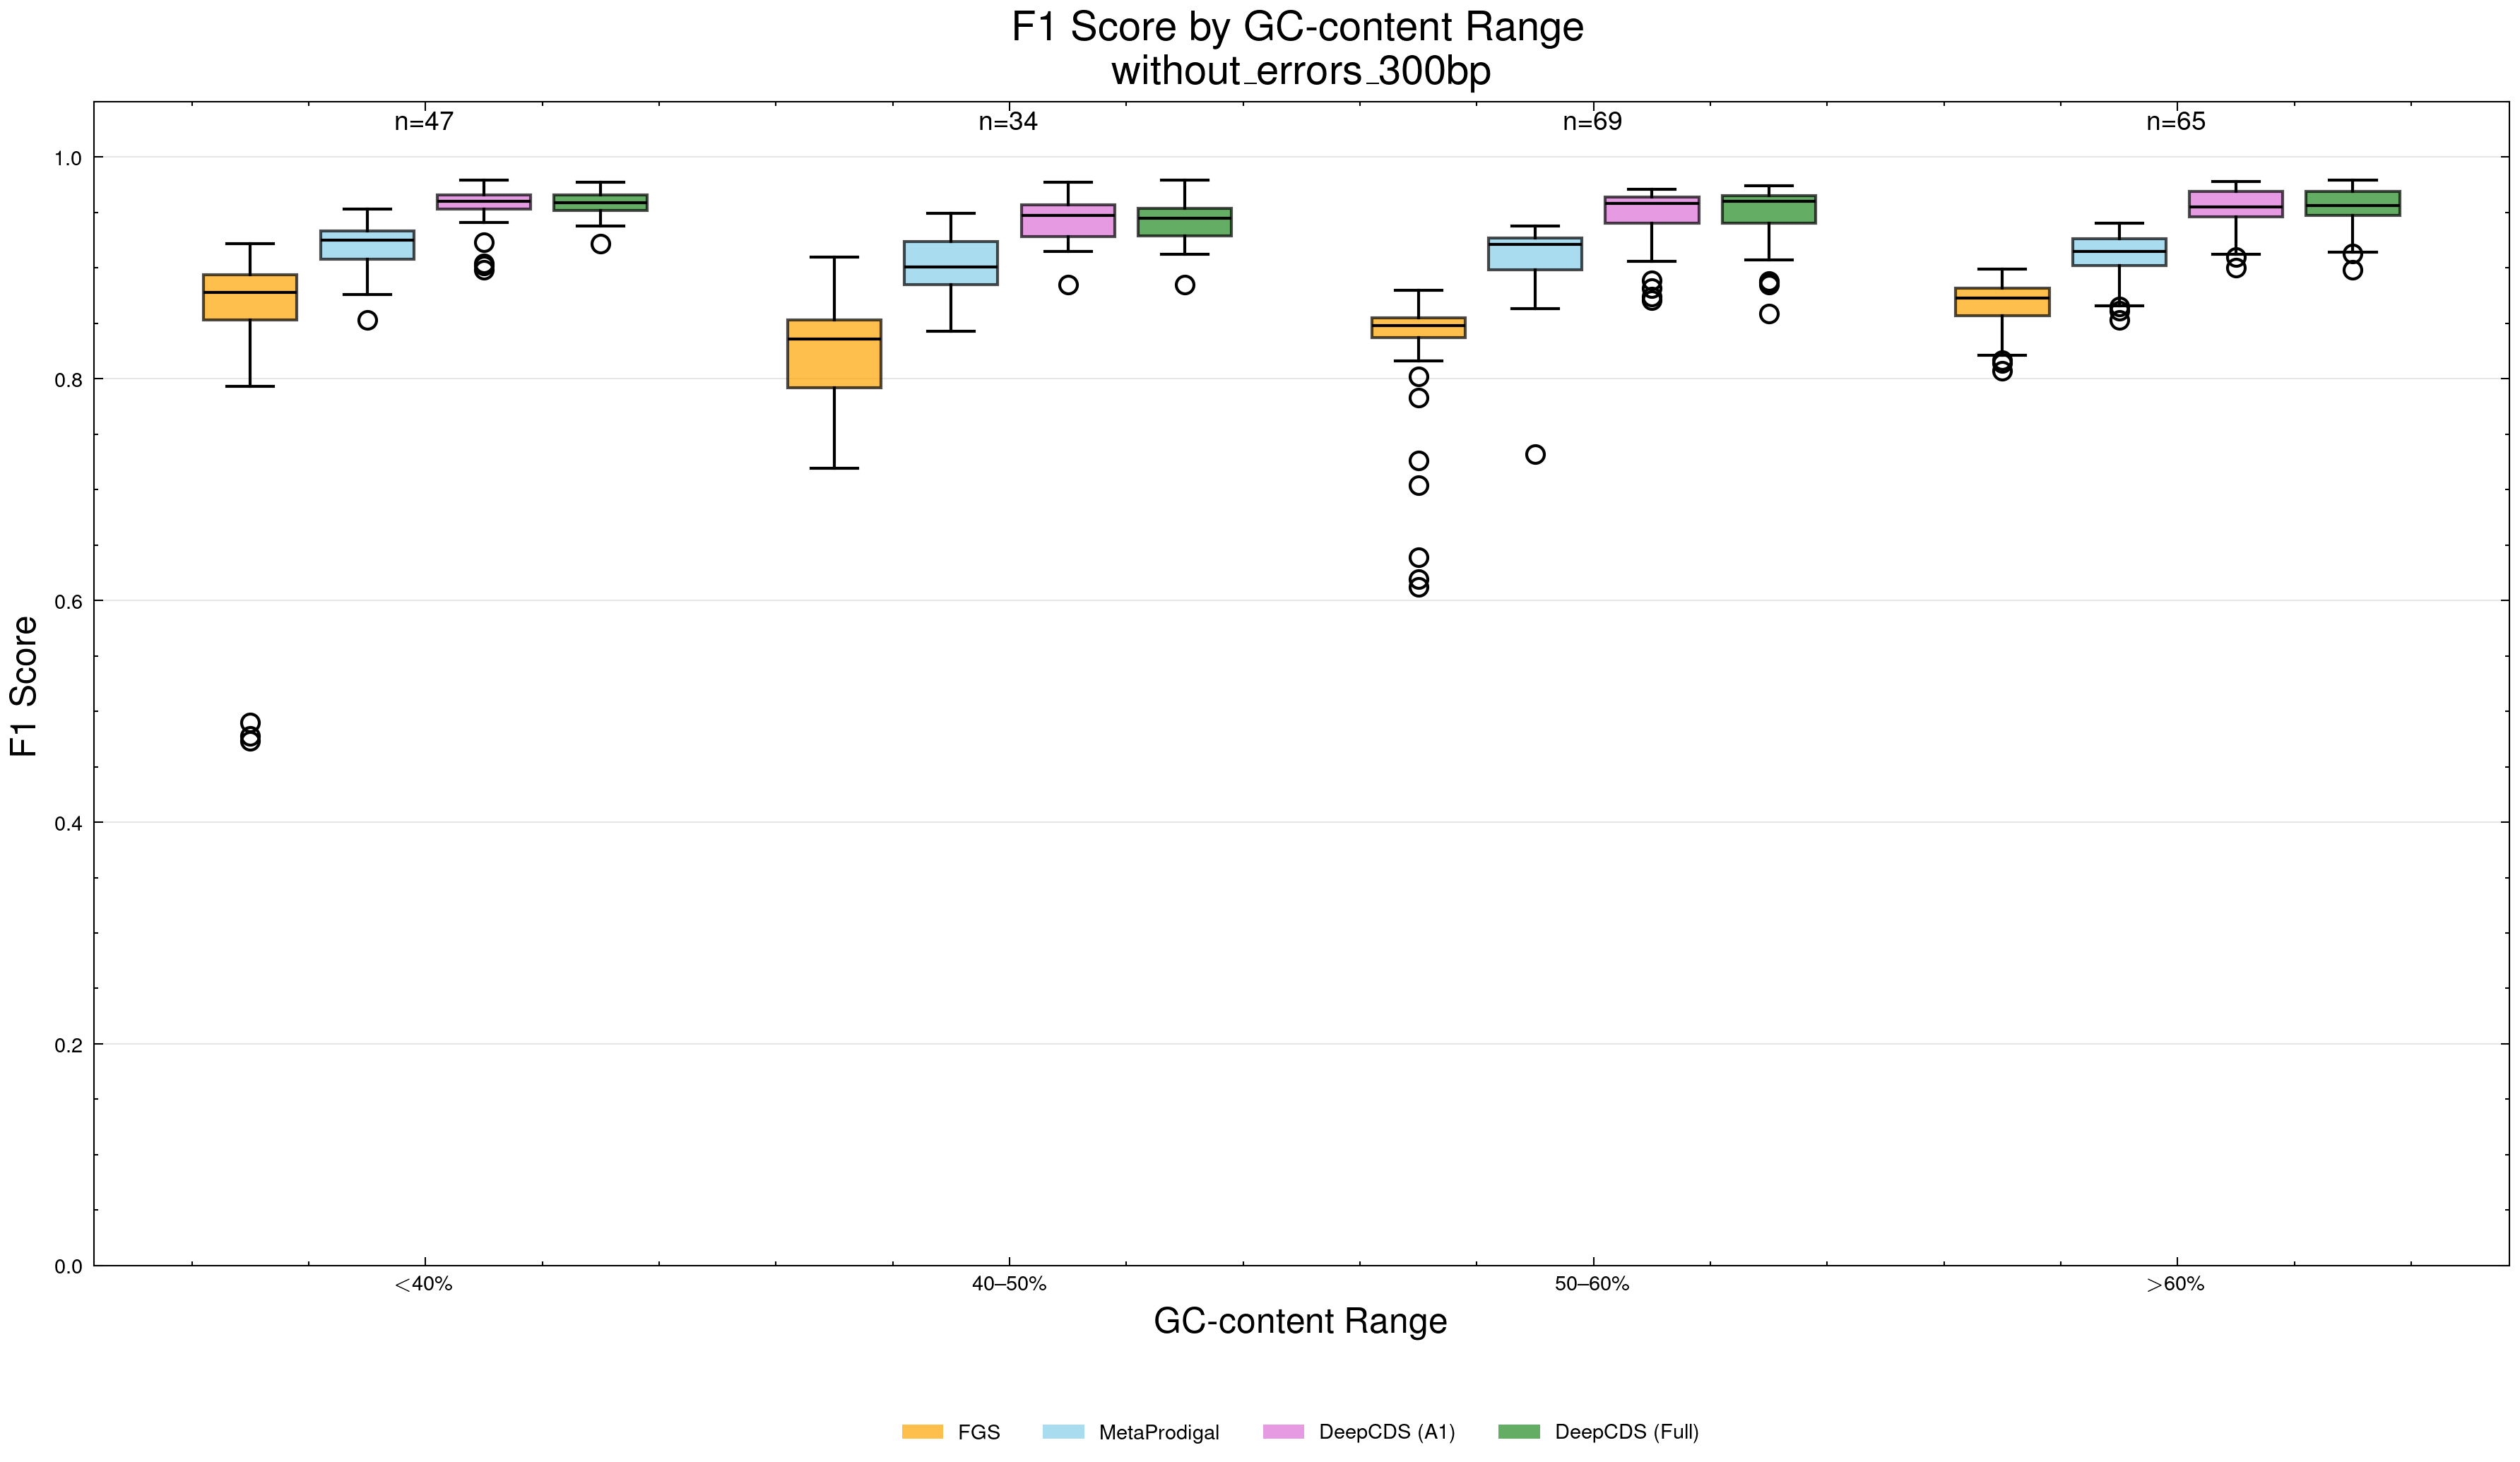

In [490]:
for data_type in data_types:
    
    # Calculate performance metrics for ALL test accessions
    all_performance_metrics_dict = {}
    overlap_criteria = 1
    
    for test_accession in tqdm(all_test_accessions, desc=f"Processing {data_type}"):
        try:
            read_names_list, testset_dict, prodigal_dict, \
            preds_fgs_dict, preds_a1, preds_deep_cds = load_in_processed_datasets(test_accession, data_type)
            
            all_performance_metrics_dict[test_accession] = {
                "fgs_complete": calculate_metrics(testset_dict, preds_fgs_dict, read_names_list, overlap_criteria),
                "prodigal": calculate_metrics(testset_dict, prodigal_dict, read_names_list, overlap_criteria),
                "deep_cds_a1": calculate_metrics(testset_dict, preds_a1, read_names_list, overlap_criteria),
                "deep_cds": calculate_metrics(testset_dict, preds_deep_cds, read_names_list, overlap_criteria)
            }
        except Exception as e:
            print(f"Error processing {test_accession}: {e}")
            continue
    
    # Define display names and colors
    model_display_names = {
        "prodigal": "MetaProdigal",
        "fgs_complete": "FGS",
        "deep_cds_a1": "DeepCDS (A1)",
        "deep_cds": "DeepCDS (Full)"
    }
    custom_colors = ['orange', 'skyblue', 'orchid', 'forestgreen']
    
    # Plot boxplots by GC-cont
    # ent
    plot_metric_by_gc_content_boxplot(all_performance_metrics_dict, all_genomes, 'f1_score', data_type,
                                      model_display_names=model_display_names, colors=custom_colors)
    #plot_metric_by_gc_content_boxplot(all_performance_metrics_dict, all_genomes, 'recall', data_type,
    #                                  model_display_names=model_display_names, colors=custom_colors)
    #plot_metric_by_gc_content_boxplot(all_performance_metrics_dict, all_genomes, 'precision', data_type,
    #                                  model_display_names=model_display_names, colors=custom_colors)

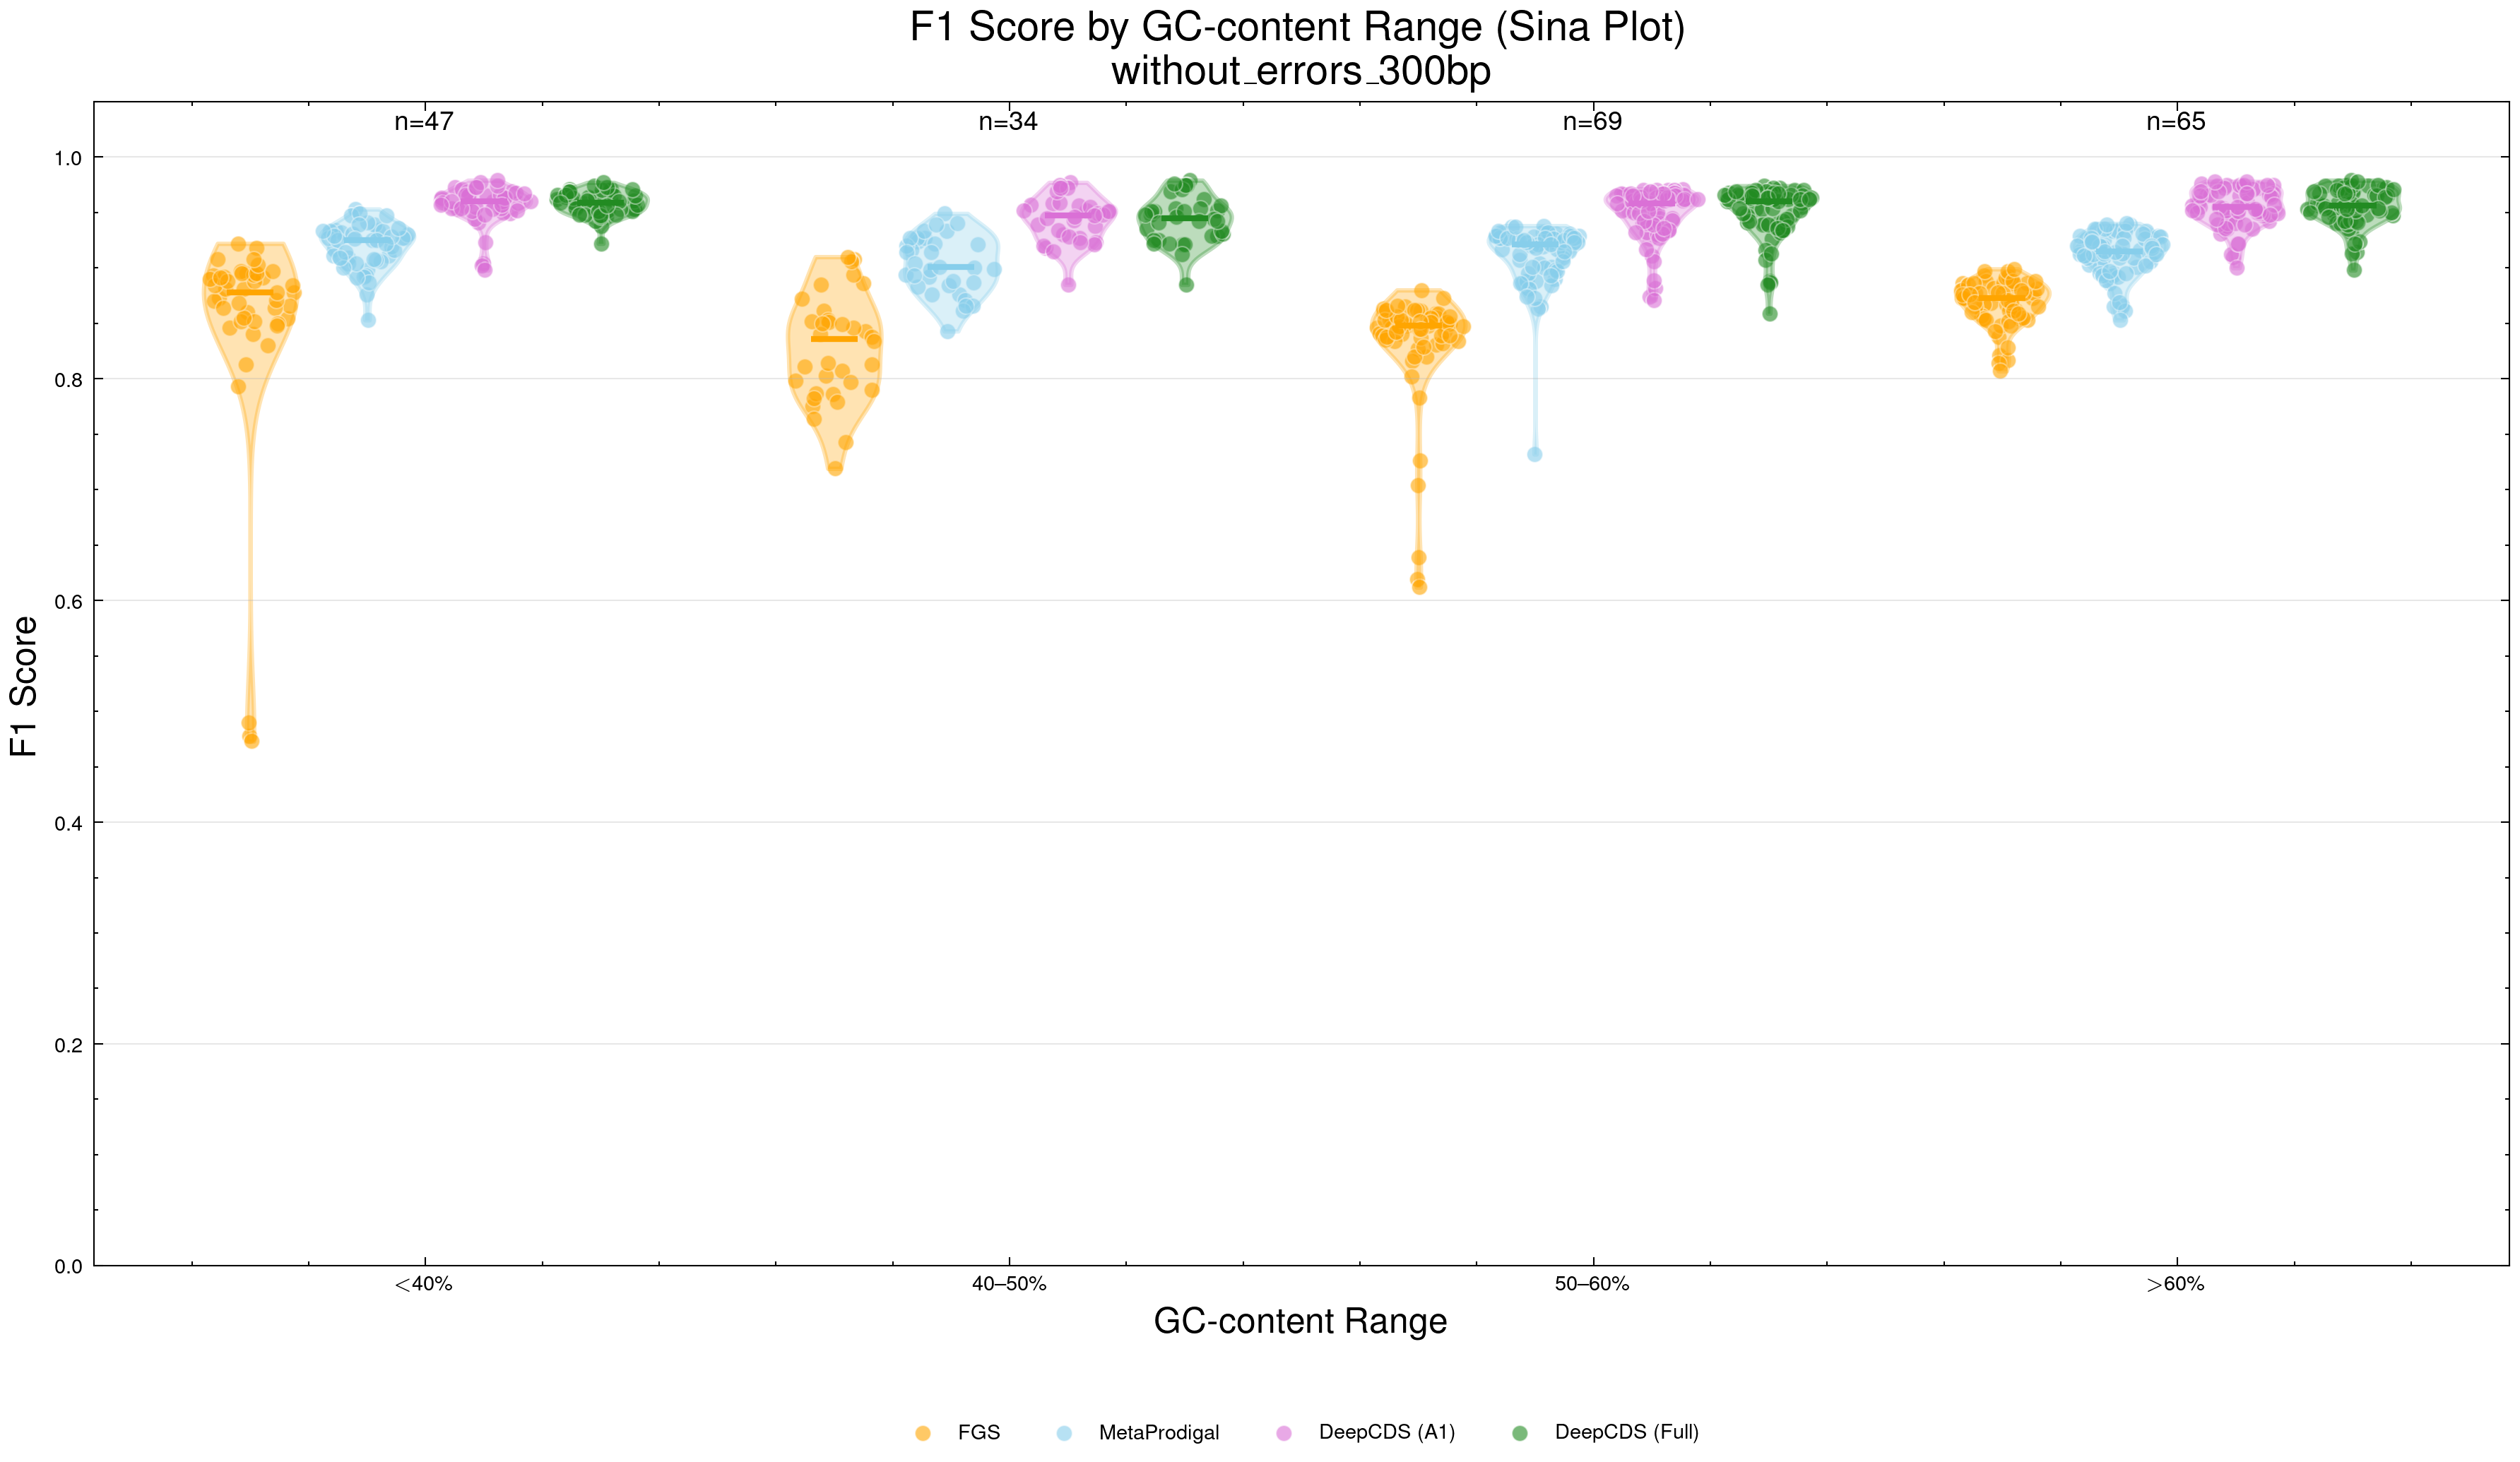

In [491]:
# Reorder the metrics dict to control bar order
def reorder_metrics(metrics_dict, order):
    """Reorder the model keys in performance metrics dict."""
    reordered = {}
    for acc, models in metrics_dict.items():
        reordered[acc] = {model: models[model] for model in order if model in models}
    return reordered

model_order = ["fgs_complete", "prodigal", "deep_cds_a1", "deep_cds"]
model_display_names_ordered = {
    "fgs_complete": "FGS",
    "prodigal": "MetaProdigal",
    "deep_cds_a1": "DeepCDS (A1)",
    "deep_cds": "DeepCDS (Full)"
}

custom_colors_ordered = ['orange', 'skyblue', 'orchid', 'forestgreen']

# Plot sina plots by GC-content
all_performance_metrics_ordered = reorder_metrics(all_performance_metrics_dict, model_order)
for data_type in data_types:
    plot_metric_by_gc_content_sina(all_performance_metrics_ordered, all_genomes, 'f1_score', data_type,
                                   model_display_names=model_display_names_ordered, colors=custom_colors_ordered,
                                   overlay='violin')
    #plot_metric_by_gc_content_sina(all_performance_metrics_ordered, all_genomes, 'recall', data_type,
    #                               model_display_names=model_display_names_ordered, colors=custom_colors_ordered,
    #                               overlay='violin')
    #plot_metric_by_gc_content_sina(all_performance_metrics_ordered, all_genomes, 'precision', data_type,
    #                               model_display_names=model_display_names_ordered, colors=custom_colors_ordered,
    #                               overlay='violin')

# Plot performance as a function of GC-content as scatterplot(aggregated to GC-content category, not genome-level)

In [492]:
def plot_metric_by_gc_content_bars(performance_metrics_dict, genome_metadata, metric_name, data_type,
                                    gc_bins=None, model_display_names=None, colors=None):
    """
    Plot barplot of aggregated performance metric by GC-content ranges.
    Aggregates all predictions within each GC bin to compute a single metric.
    
    Args:
        performance_metrics_dict (dict): Dictionary with genome accessions as keys and model metrics as values
        genome_metadata (dict): Dictionary with genome metadata including gc_content
        metric_name (str): Name of the metric to plot (e.g., 'f1_score', 'precision', 'recall')
        data_type (str): Data type description for the plot title
        gc_bins (list, optional): List of bin edges for GC-content. Default: [0, 40, 50, 60, 100]
        model_display_names (dict, optional): Dictionary mapping model names to display names
        colors (list, optional): List of colors for each model
    """
    if gc_bins is None:
        gc_bins = [0, 40, 50, 60, 100]
    
    # Get model names from the first genome entry
    first_genome = next(iter(performance_metrics_dict.values()))
    model_names = list(first_genome.keys())
    
    # Set up display names
    if model_display_names is None:
        display_names = {name: name for name in model_names}
    else:
        display_names = model_display_names
    
    # Set up colors
    if colors is None:
        colors = ['orange', 'skyblue', 'orchid', 'forestgreen', 'purple']
    
    # Create bin labels
    bin_labels = []
    for i in range(len(gc_bins) - 1):
        if gc_bins[i] == 0:
            bin_labels.append(rf"$<${gc_bins[i+1]}\%")
        elif gc_bins[i+1] == 100:
            bin_labels.append(rf"$>${gc_bins[i]}\%")
        else:
            bin_labels.append(rf"{gc_bins[i]}--{gc_bins[i+1]}\%")
    
    # Aggregate raw counts by GC bin and model
    aggregated_counts = {label: {model: {'tp': 0, 'fp': 0, 'fn': 0, 'count': 0} 
                                  for model in model_names} 
                         for label in bin_labels}
    
    for acc, metrics in performance_metrics_dict.items():
        if acc not in genome_metadata:
            continue
        
        gc = genome_metadata[acc]['gc_content']
        
        # Find the appropriate bin
        bin_label = None
        for i in range(len(gc_bins) - 1):
            if gc_bins[i] <= gc < gc_bins[i + 1]:
                bin_label = bin_labels[i]
                break
        
        if bin_label is None:
            continue
        
        # Aggregate counts for each model
        for model in model_names:
            if model in metrics:
                aggregated_counts[bin_label][model]['tp'] += metrics[model].get('total_true_positives', 0)
                aggregated_counts[bin_label][model]['fp'] += metrics[model].get('total_false_positives', 0)
                aggregated_counts[bin_label][model]['fn'] += metrics[model].get('total_false_negatives', 0)
                aggregated_counts[bin_label][model]['count'] += 1
    
    # Calculate aggregated metrics for each bin and model
    aggregated_metrics = {model: [] for model in model_names}
    genome_counts = []
    
    for i, label in enumerate(bin_labels):
        genome_counts.append(aggregated_counts[label][model_names[0]]['count'])
        
        for model in model_names:
            counts = aggregated_counts[label][model]
            tp, fp, fn = counts['tp'], counts['fp'], counts['fn']
            
            # Calculate metrics from aggregated counts
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            
            if metric_name == 'f1_score':
                aggregated_metrics[model].append(f1)
            elif metric_name == 'precision':
                aggregated_metrics[model].append(precision)
            elif metric_name == 'recall':
                aggregated_metrics[model].append(recall)
    
    # Create the barplot
    fig, ax = plt.subplots(figsize=(12, 7))
    
    n_models = len(model_names)
    n_bins = len(bin_labels)
    x = np.arange(n_bins)
    width = 0.8 / n_models
    
    # Create bars for each model
    for i, model in enumerate(model_names):
        x_pos = x - (n_models - 1) * width / 2 + i * width
        bars = ax.bar(x_pos, aggregated_metrics[model], width,
                     label=display_names.get(model, model),
                     color=colors[i % len(colors)], alpha=0.8)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
    # Customize the plot
    ax.set_xlabel('GC-content Range', fontsize=12)
    ax.set_ylabel(metric_name.replace("_", " ").title(), fontsize=12)
    ax.set_title(f'Aggregated {metric_name.replace("_", " ").title()} by GC-content Range\n{data_type}', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels)
    
    # Add genome count annotations
    for i, count in enumerate(genome_counts):
        ax.text(i, ax.get_ylim()[1] * 0.99, f'n={count}', ha='center', va='top', fontsize=9)
    
    # Add legend
    ax.legend(bbox_to_anchor=(0.5, -0.12), loc='upper center', ncol=min(4, n_models))
    
    # Add grid
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0.0, 1.05)
    
    plt.tight_layout()
    plt.show()

In [493]:
def plot_metric_per_family_bars(performance_metrics_dict, genome_metadata, metric_name, data_type,
                                 model_display_names=None, colors=None, min_genomes=1):
    """
    Plot barplot of aggregated performance metric per family.
    Aggregates all predictions within each family to compute a single metric.
    
    Args:
        performance_metrics_dict (dict): Dictionary with genome accessions as keys and model metrics as values
        genome_metadata (dict): Dictionary with genome metadata including family
        metric_name (str): Name of the metric to plot (e.g., 'f1_score', 'precision', 'recall')
        data_type (str): Data type description for the plot title
        model_display_names (dict, optional): Dictionary mapping model names to display names
        colors (list, optional): List of colors for each model
        min_genomes (int): Minimum number of genomes required to include a family. Default: 1
    """
    # Get model names from the first genome entry
    first_genome = next(iter(performance_metrics_dict.values()))
    model_names = list(first_genome.keys())
    
    # Set up display names
    if model_display_names is None:
        display_names = {name: name for name in model_names}
    else:
        display_names = model_display_names
    
    # Set up colors
    if colors is None:
        colors = ['orange', 'skyblue', 'orchid', 'forestgreen', 'purple']
    
    # Get all unique families
    families = set()
    for acc in performance_metrics_dict.keys():
        if acc in genome_metadata:
            families.add(genome_metadata[acc]['family'])
    
    # Aggregate raw counts by family and model
    aggregated_counts = {family: {model: {'tp': 0, 'fp': 0, 'fn': 0, 'count': 0} 
                                   for model in model_names} 
                         for family in families}
    
    for acc, metrics in performance_metrics_dict.items():
        if acc not in genome_metadata:
            continue
        
        family = genome_metadata[acc]['family']
        
        # Aggregate counts for each model
        for model in model_names:
            if model in metrics:
                aggregated_counts[family][model]['tp'] += metrics[model].get('total_true_positives', 0)
                aggregated_counts[family][model]['fp'] += metrics[model].get('total_false_positives', 0)
                aggregated_counts[family][model]['fn'] += metrics[model].get('total_false_negatives', 0)
                aggregated_counts[family][model]['count'] += 1
    
    # Filter families by minimum genome count
    valid_families = [f for f in families if aggregated_counts[f][model_names[0]]['count'] >= min_genomes]
    
    # Calculate aggregated metrics for each family and model
    aggregated_metrics = {model: [] for model in model_names}
    genome_counts = []
    family_labels = []
    
    # Sort families by the first model's F1 score for better visualization
    family_scores = []
    for family in valid_families:
        counts = aggregated_counts[family][model_names[0]]
        tp, fp, fn = counts['tp'], counts['fp'], counts['fn']
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        family_scores.append((family, f1))
    
    # Sort by score descending
    sorted_families = [f for f, _ in sorted(family_scores, key=lambda x: x[1], reverse=True)]
    
    for family in sorted_families:
        genome_counts.append(aggregated_counts[family][model_names[0]]['count'])
        family_labels.append(family)
        
        for model in model_names:
            counts = aggregated_counts[family][model]
            tp, fp, fn = counts['tp'], counts['fp'], counts['fn']
            
            # Calculate metrics from aggregated counts
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            
            if metric_name == 'f1_score':
                aggregated_metrics[model].append(f1)
            elif metric_name == 'precision':
                aggregated_metrics[model].append(precision)
            elif metric_name == 'recall':
                aggregated_metrics[model].append(recall)
    
    # Create the barplot
    n_families = len(sorted_families)
    n_models = len(model_names)
    
    fig, ax = plt.subplots(figsize=(max(14, n_families * 0.8), 8))
    
    x = np.arange(n_families)
    width = 0.8 / n_models
    
    # Create bars for each model
    for i, model in enumerate(model_names):
        x_pos = x - (n_models - 1) * width / 2 + i * width
        bars = ax.bar(x_pos, aggregated_metrics[model], width,
                     label=display_names.get(model, model),
                     color=colors[i % len(colors)], alpha=0.8)
    
    # Customize the plot
    ax.set_xlabel('Family', fontsize=12)
    ax.set_ylabel(metric_name.replace("_", " ").title(), fontsize=12)
    ax.set_title(f'Aggregated {metric_name.replace("_", " ").title()} per Family\n{data_type}', fontsize=14)
    ax.set_xticks(x)
    
    # Create x-axis labels with genome count
    x_labels = [f"{fam}\n(n={cnt})" for fam, cnt in zip(family_labels, genome_counts)]
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
    
    # Add legend
    ax.legend(bbox_to_anchor=(0.5, -0.25), loc='upper center', ncol=min(4, n_models))
    
    # Add grid
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0.0, 1.05)
    
    plt.tight_layout()
    plt.show()
    
    return sorted_families, aggregated_metrics

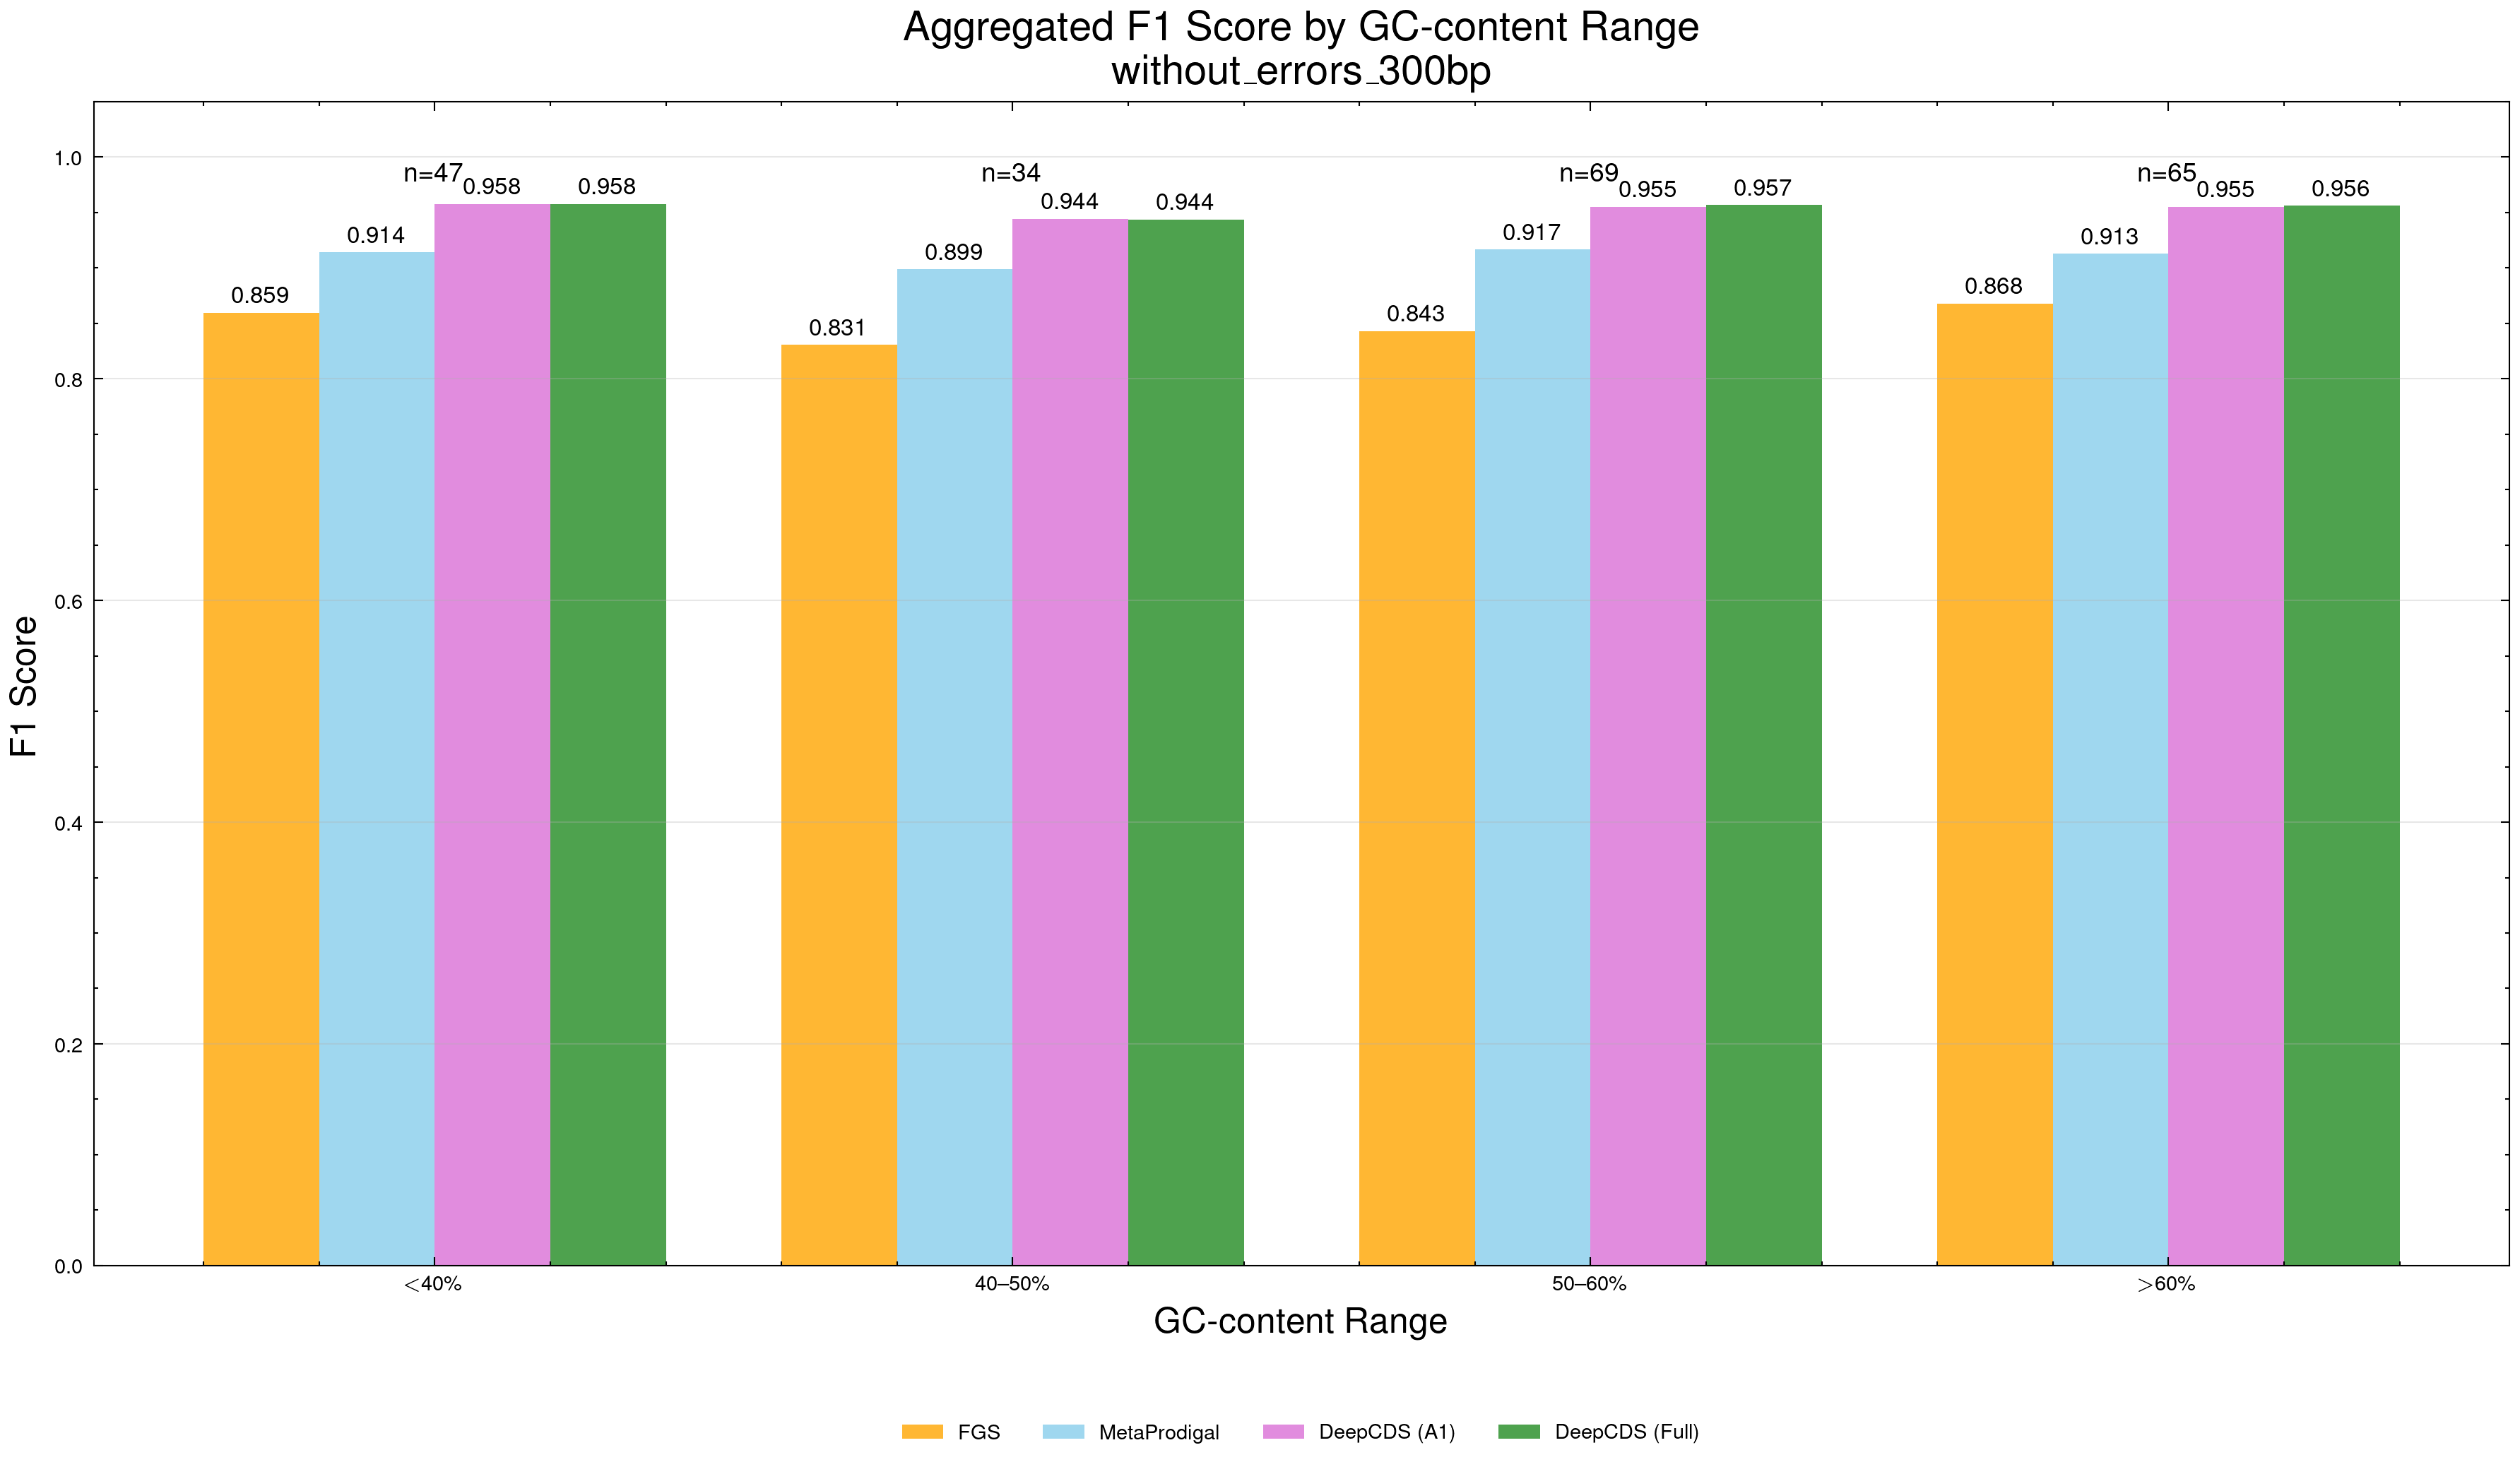

In [494]:
for data_type in data_types:
    plot_metric_by_gc_content_bars(all_performance_metrics_ordered, all_genomes, 'f1_score', data_type,
                                   model_display_names=model_display_names_ordered, colors=custom_colors_ordered)
    #plot_metric_by_gc_content_bars(all_performance_metrics_ordered, all_genomes, 'recall', data_type,
    #                               model_display_names=model_display_names_ordered, colors=custom_colors_ordered)
    #plot_metric_by_gc_content_bars(all_performance_metrics_ordered, all_genomes, 'precision', data_type,
    #                               model_display_names=model_display_names_ordered, colors=custom_colors_ordered)

# Plot performance per Family

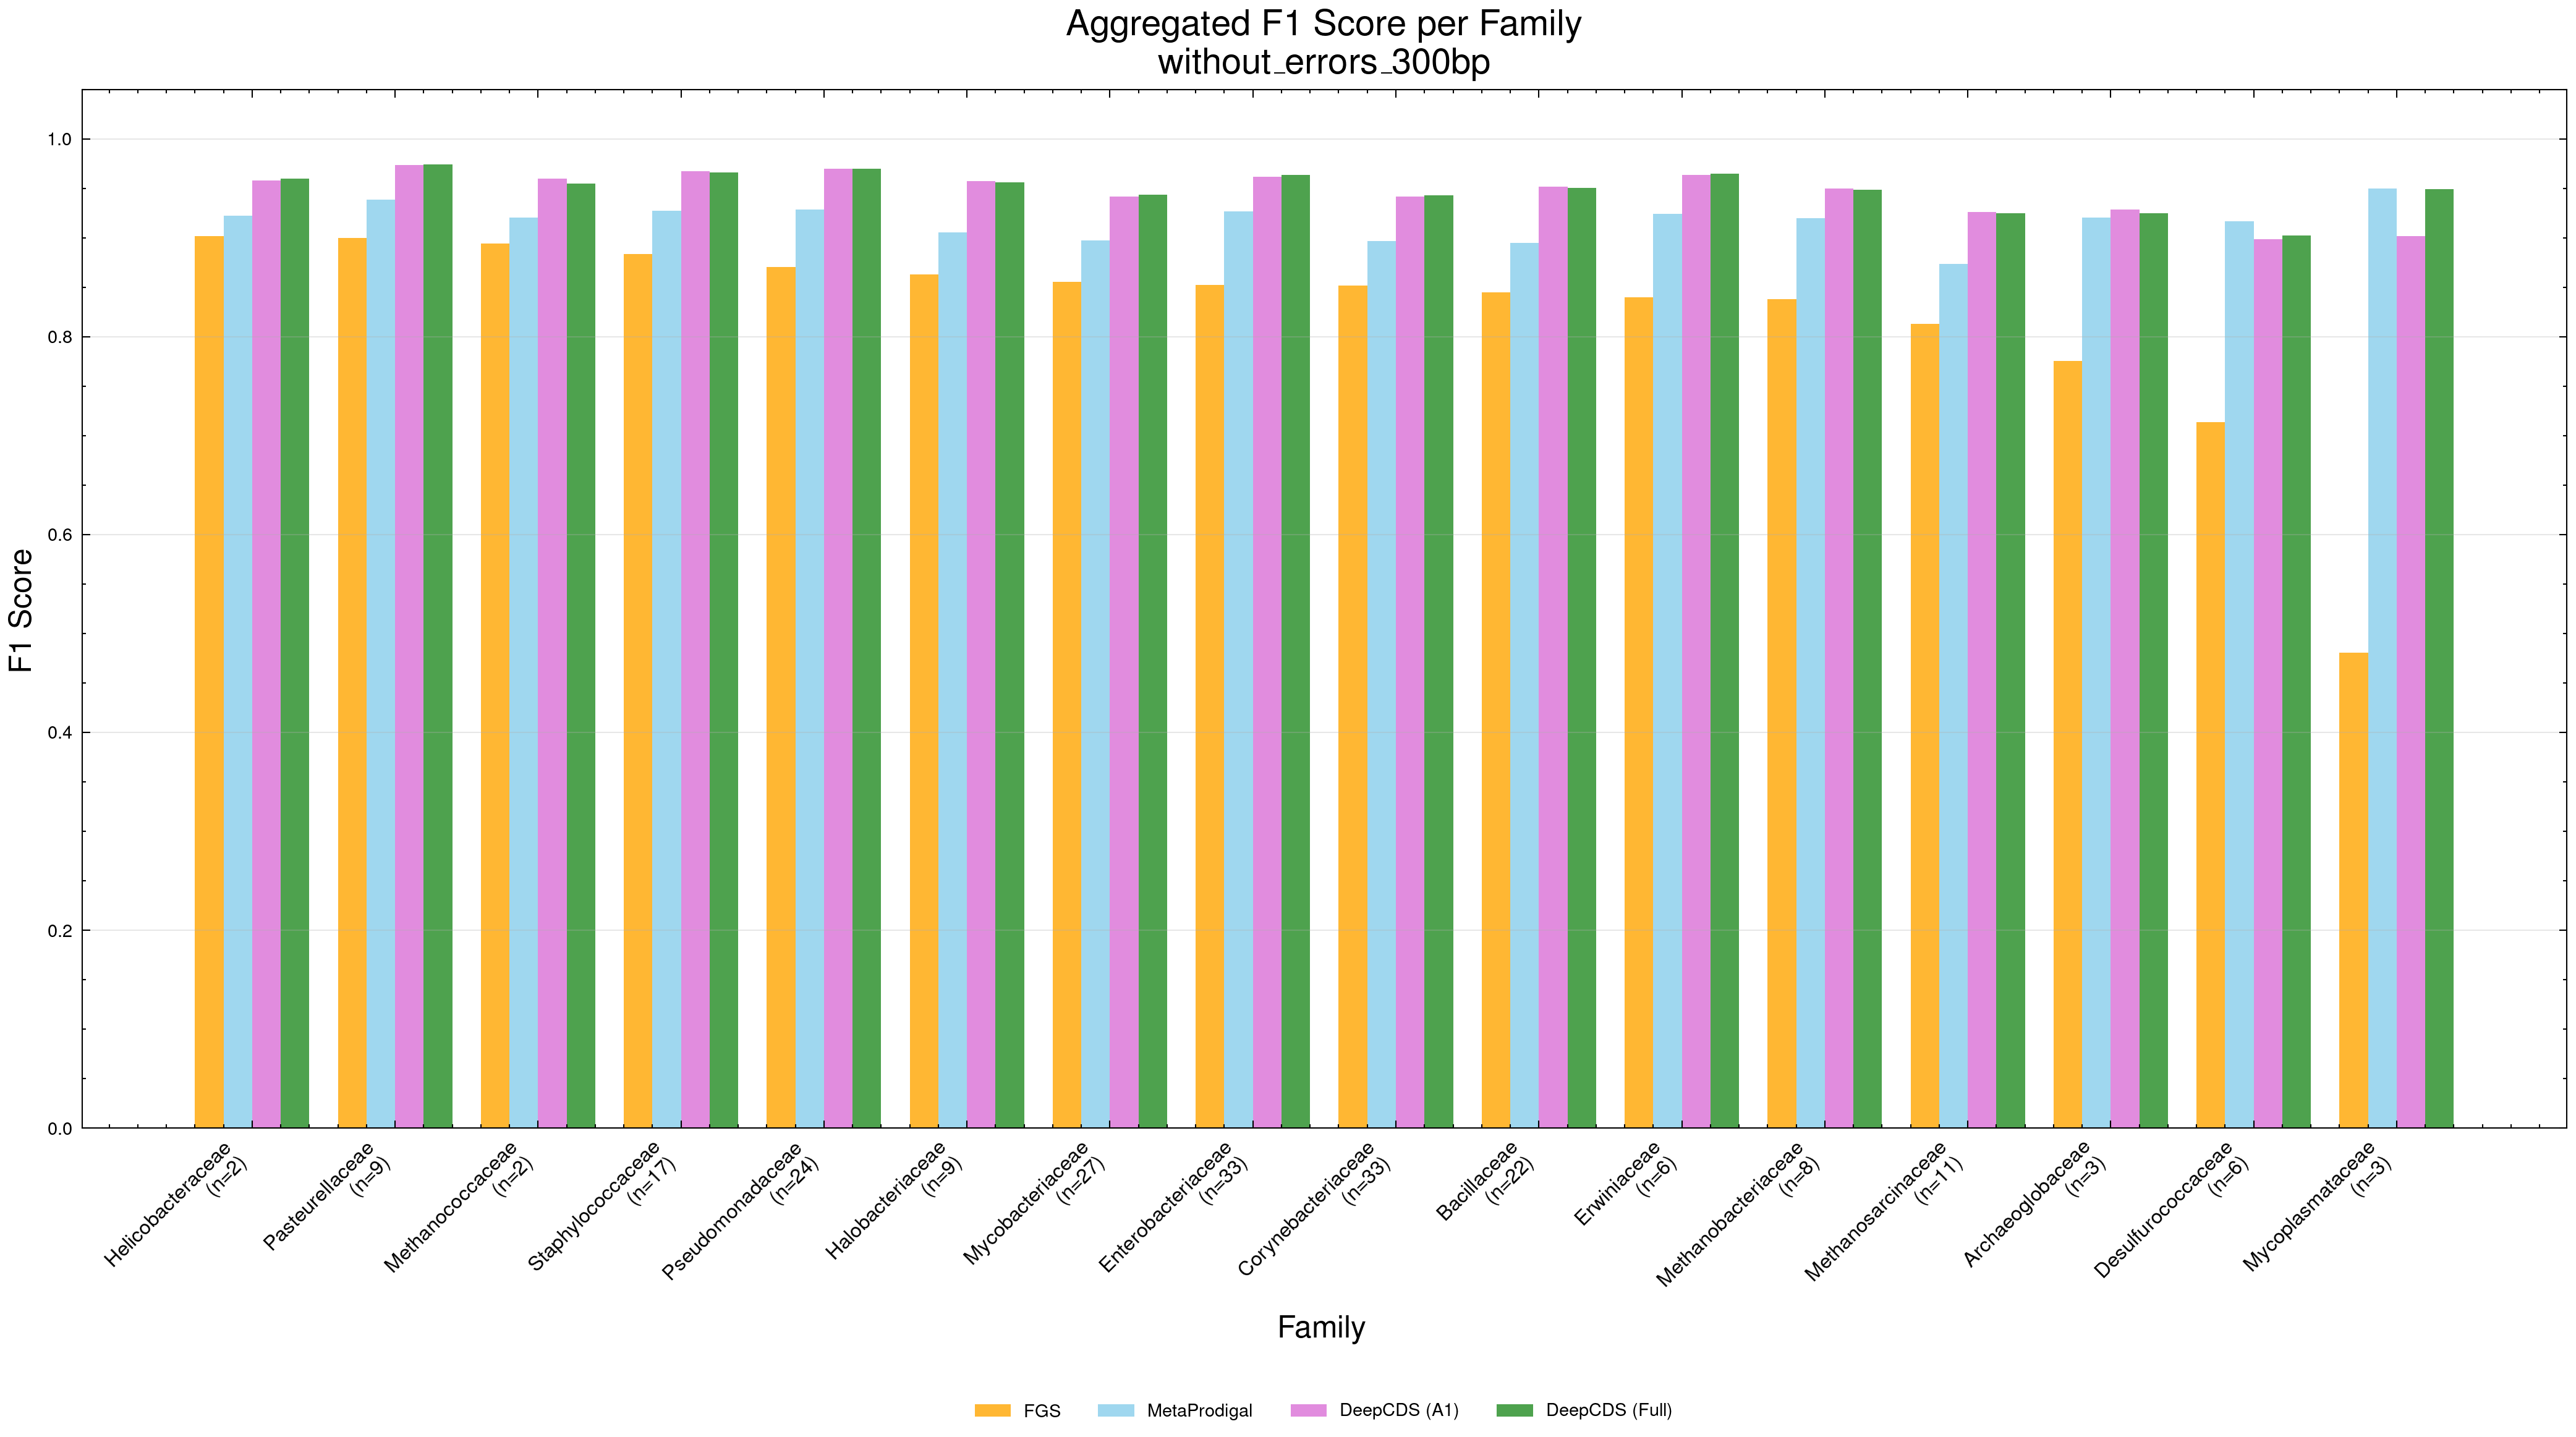

In [495]:
# Plot performance per family (aggregated across all genomes in each family)
for data_type in data_types:
    plot_metric_per_family_bars(all_performance_metrics_ordered, all_genomes, 'f1_score', data_type,
                                model_display_names=model_display_names_ordered, colors=custom_colors_ordered)
    #plot_metric_per_family_bars(all_performance_metrics_ordered, all_genomes, 'recall', data_type,
    #                            model_display_names=model_display_names_ordered, colors=custom_colors_ordered)
    #plot_metric_per_family_bars(all_performance_metrics_ordered, all_genomes, 'precision', data_type,
    #                            model_display_names=model_display_names_ordered, colors=custom_colors_ordered)

In [496]:
# Generate LaTeX table for per-family performance (F1, Sensitivity, Precision)
def generate_family_latex_table(performance_metrics_dict, genome_metadata, model_order, model_display_names):
    """Generate a LaTeX booktabs table with family rows and model columns, best per family bolded."""
    model_names = model_order
    
    # Get all unique families and aggregate counts
    families = set()
    for acc in performance_metrics_dict.keys():
        if acc in genome_metadata:
            families.add(genome_metadata[acc]['family'])
    
    aggregated_counts = {family: {model: {'tp': 0, 'fp': 0, 'fn': 0, 'count': 0}
                                   for model in model_names}
                         for family in families}
    
    for acc, metrics in performance_metrics_dict.items():
        if acc not in genome_metadata:
            continue
        family = genome_metadata[acc]['family']
        for model in model_names:
            if model in metrics:
                aggregated_counts[family][model]['tp'] += metrics[model].get('total_true_positives', 0)
                aggregated_counts[family][model]['fp'] += metrics[model].get('total_false_positives', 0)
                aggregated_counts[family][model]['fn'] += metrics[model].get('total_false_negatives', 0)
                aggregated_counts[family][model]['count'] += 1
    
    # Compute metrics per family per model
    family_metrics = {}
    for family in families:
        family_metrics[family] = {}
        for model in model_names:
            c = aggregated_counts[family][model]
            tp, fp, fn = c['tp'], c['fp'], c['fn']
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            family_metrics[family][model] = {'f1_score': f1, 'recall': recall, 'precision': precision}
    
    # Sort families alphabetically
    sorted_families = sorted(families)
    
    # Get genome counts per family
    genome_counts = {f: aggregated_counts[f][model_names[0]]['count'] for f in sorted_families}
    
    # Build LaTeX
    col_headers = [model_display_names.get(m, m) for m in model_names]
    n_cols = len(model_names)
    
    latex = []
    latex.append(r"\begin{table}[ht]")
    latex.append(r"\centering")
    latex.append(r"\begin{tabular}{l" + "c" * n_cols + "}")
    latex.append(r"\toprule")
    latex.append("Family (n) & " + " & ".join(col_headers) + r" \\")
    
    for metric_key, metric_label in [('f1_score', 'F1 Score')]:
        latex.append(r"\midrule")
        latex.append(r"\multicolumn{" + str(n_cols + 1) + r"}{l}{\textit{" + metric_label + r"}} \\")
        
        for family in sorted_families:
            values = [family_metrics[family][m][metric_key] for m in model_names]
            max_val = max(values)
            
            cells = []
            for v in values:
                formatted = f"{v:.3f}"
                if v == max_val:
                    cells.append(r"\textbf{" + formatted + "}")
                else:
                    cells.append(formatted)
            
            family_label = family + f" ({genome_counts[family]})"
            latex.append(family_label + " & " + " & ".join(cells) + r" \\")
    
    latex.append(r"\bottomrule")
    latex.append(r"\end{tabular}")
    latex.append(r"\caption{Aggregated CDS-level performance per family}")
    latex.append(r"\label{tab:family_performance}")
    latex.append(r"\end{table}")
    
    return "\n".join(latex)

for data_type in data_types:
    table = generate_family_latex_table(all_performance_metrics_ordered, all_genomes, model_order, model_display_names_ordered)
    print(table)

\begin{table}[ht]
\centering
\begin{tabular}{lcccc}
\toprule
Family (n) & FGS & MetaProdigal & DeepCDS (A1) & DeepCDS (Full) \\
\midrule
\multicolumn{5}{l}{\textit{F1 Score}} \\
Archaeoglobaceae (3) & 0.775 & 0.920 & \textbf{0.928} & 0.925 \\
Bacillaceae (22) & 0.845 & 0.895 & \textbf{0.952} & 0.950 \\
Corynebacteriaceae (33) & 0.851 & 0.896 & 0.942 & \textbf{0.943} \\
Desulfurococcaceae (6) & 0.714 & \textbf{0.917} & 0.898 & 0.902 \\
Enterobacteriaceae (33) & 0.852 & 0.927 & 0.962 & \textbf{0.963} \\
Erwiniaceae (6) & 0.840 & 0.924 & 0.963 & \textbf{0.965} \\
Halobacteriaceae (9) & 0.863 & 0.905 & \textbf{0.957} & 0.956 \\
Helicobacteraceae (2) & 0.901 & 0.922 & 0.958 & \textbf{0.960} \\
Methanobacteriaceae (8) & 0.838 & 0.920 & \textbf{0.950} & 0.949 \\
Methanococcaceae (2) & 0.894 & 0.920 & \textbf{0.960} & 0.955 \\
Methanosarcinaceae (11) & 0.813 & 0.873 & \textbf{0.926} & 0.925 \\
Mycobacteriaceae (27) & 0.855 & 0.897 & 0.941 & \textbf{0.943} \\
Mycoplasmataceae (3) & 0.480 & \tex

# Plot performance by GC-content separated by Translation Table

In [497]:
# Filter performance metrics by translation table
tt4_performance_metrics = {acc: metrics for acc, metrics in all_performance_metrics_dict.items() 
                           if acc in all_genomes and all_genomes[acc]['translation_table'] == 4}
tt11_performance_metrics = {acc: metrics for acc, metrics in all_performance_metrics_dict.items() 
                            if acc in all_genomes and all_genomes[acc]['translation_table'] == 11}

print(f"TT4 genomes with metrics: {len(tt4_performance_metrics)}")
print(f"TT11 genomes with metrics: {len(tt11_performance_metrics)}")

TT4 genomes with metrics: 3
TT11 genomes with metrics: 212


TRANSLATION TABLE 11 (Standard Bacterial/Archaeal Code)


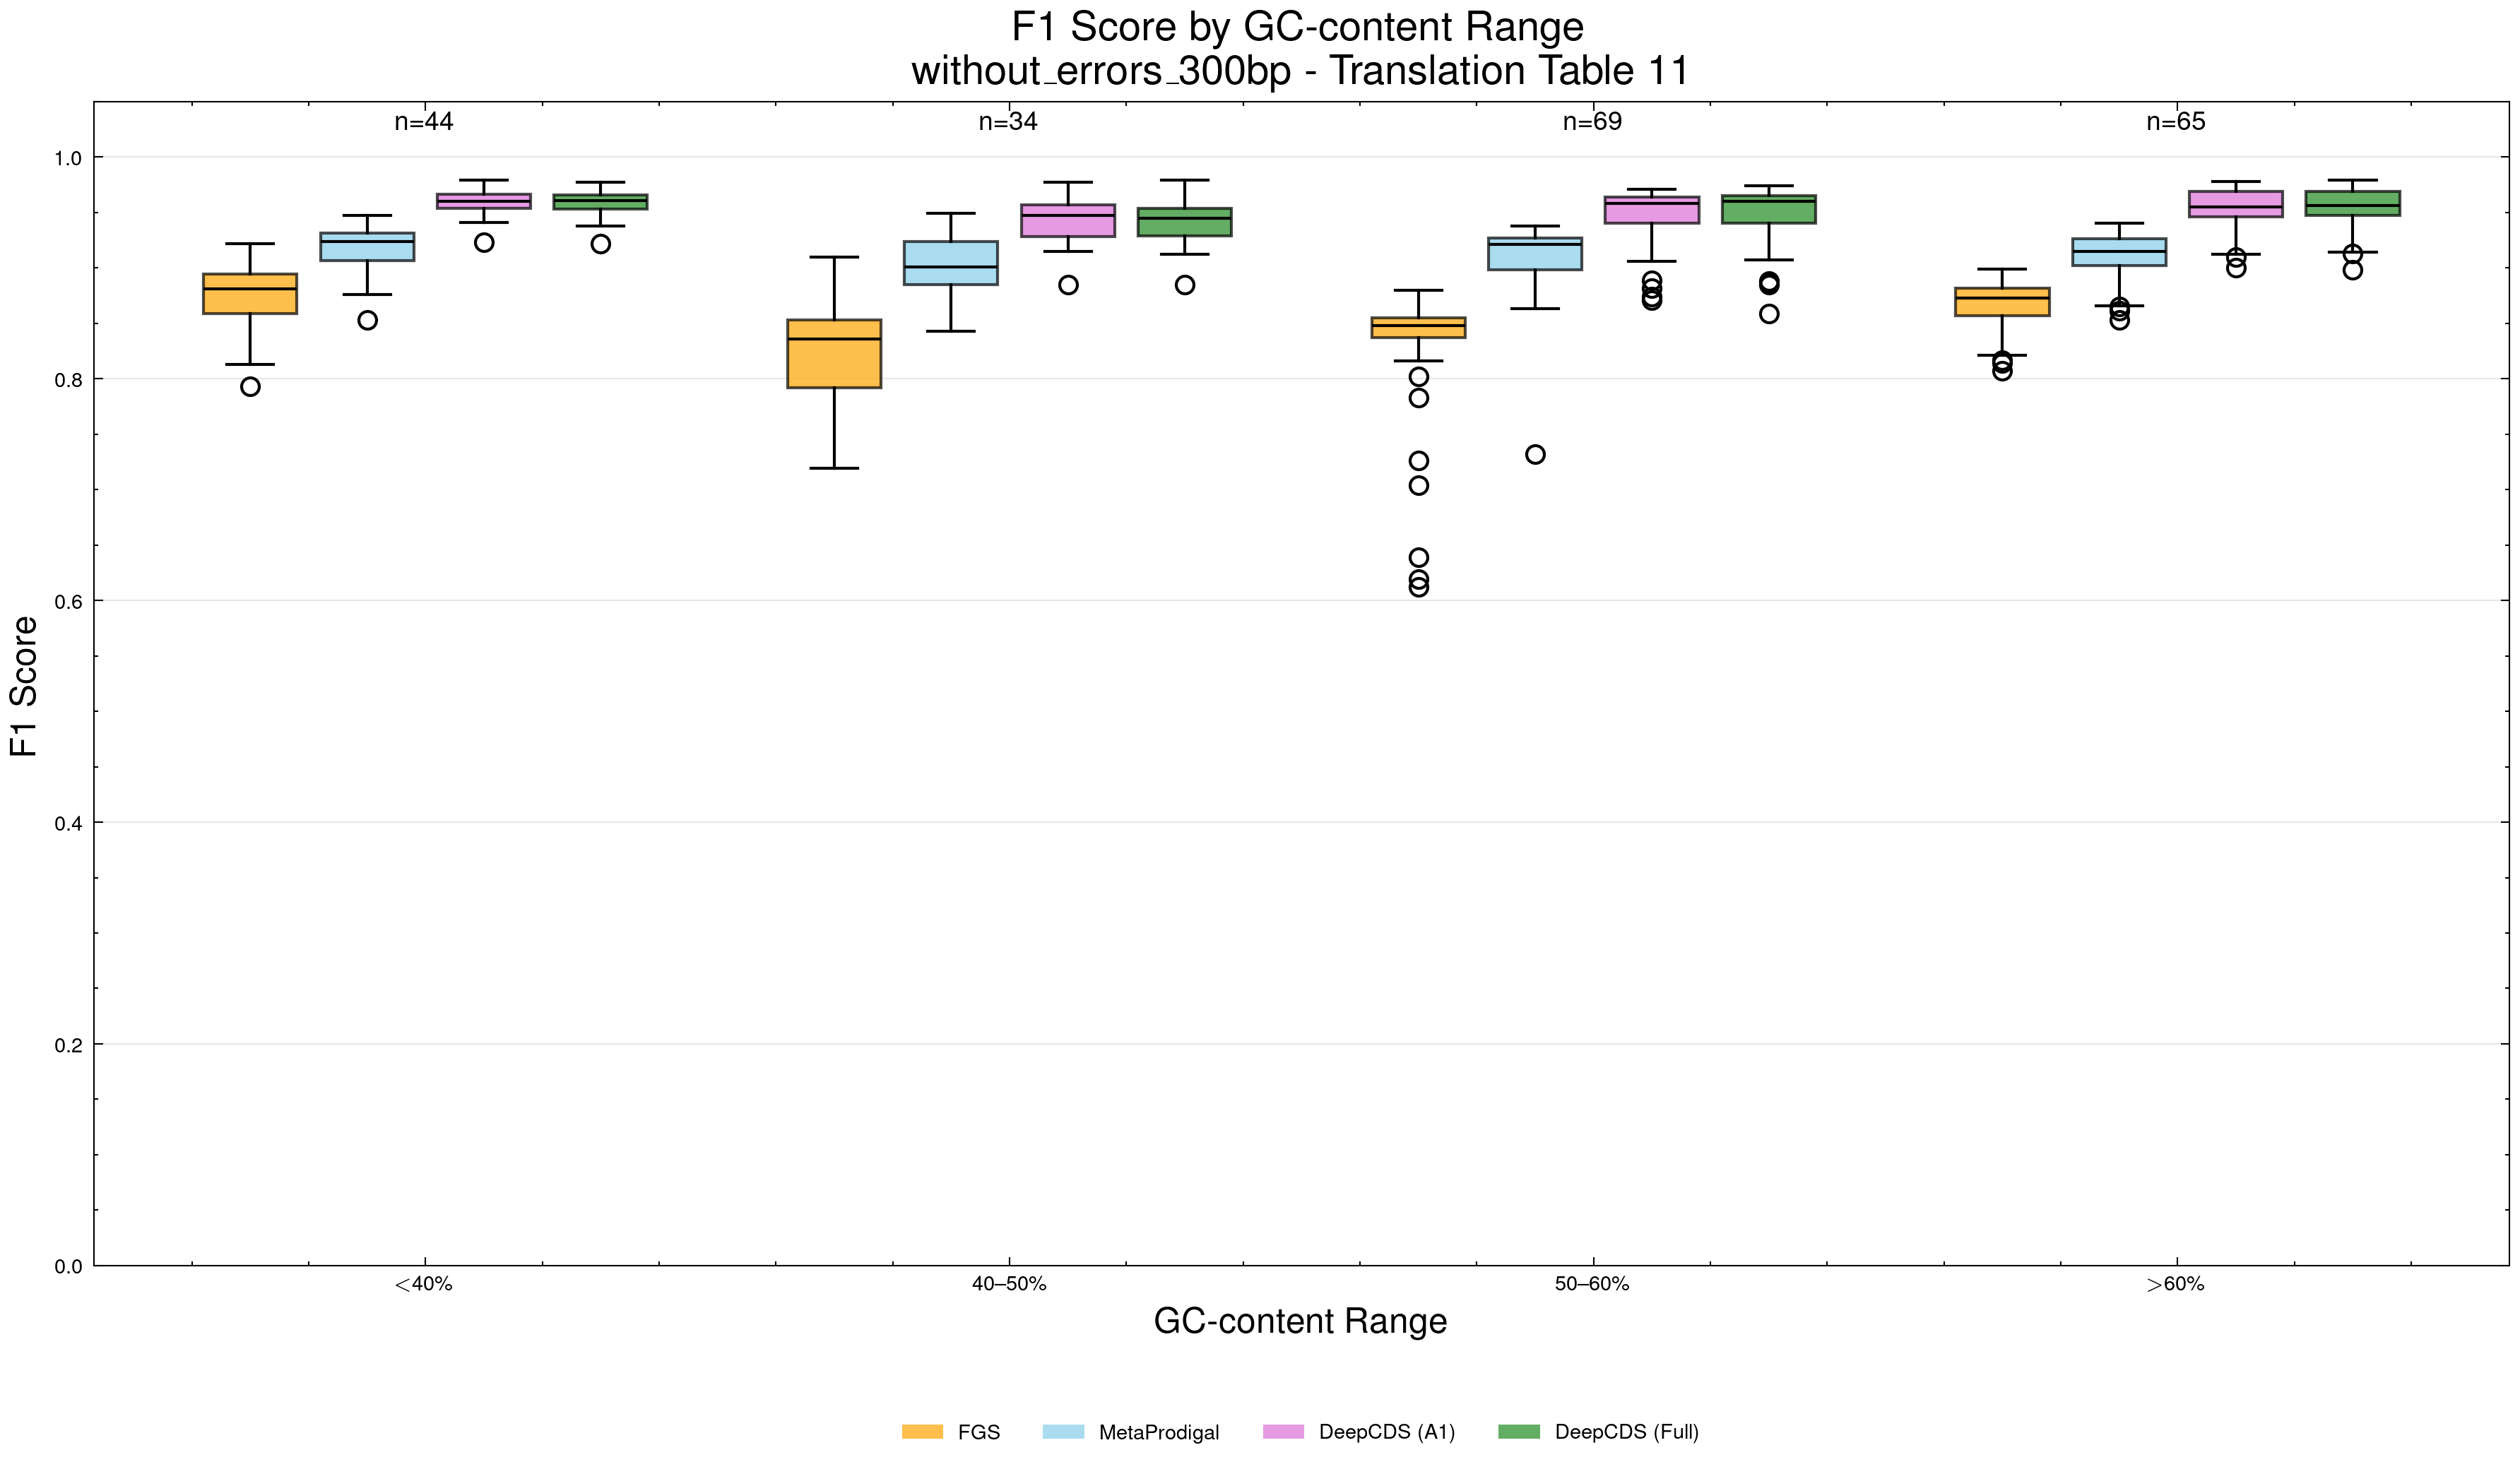

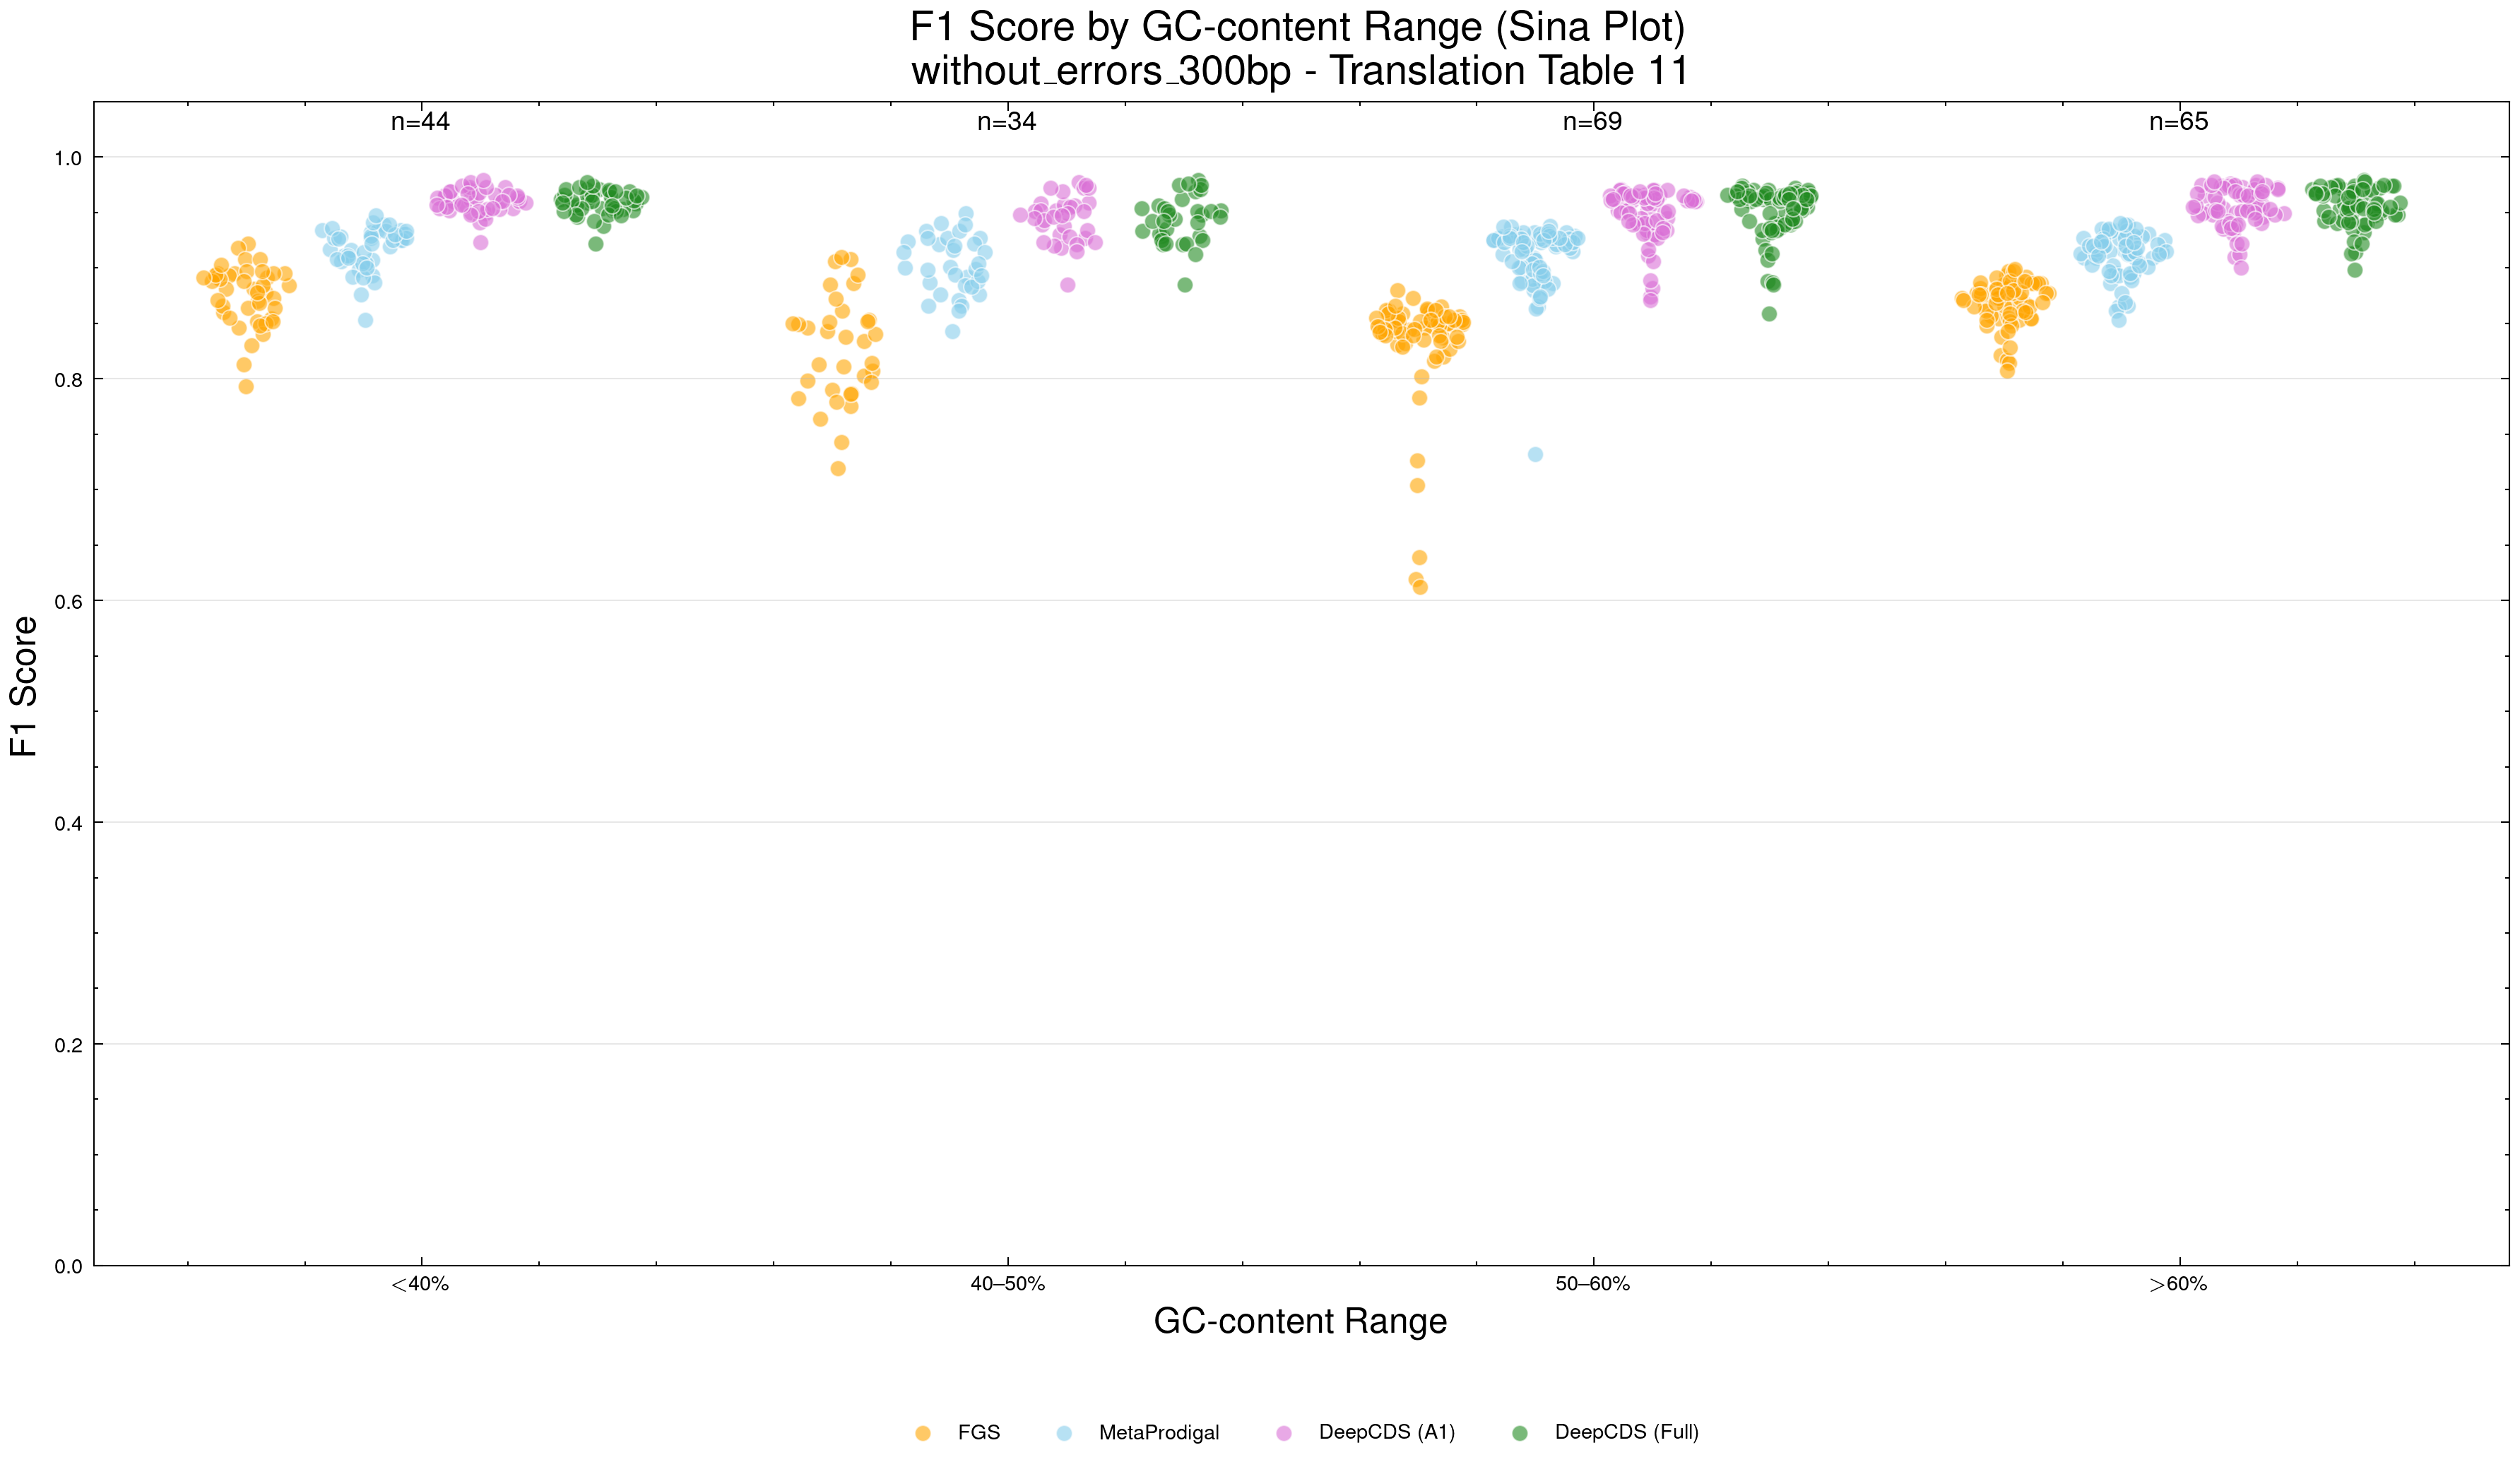

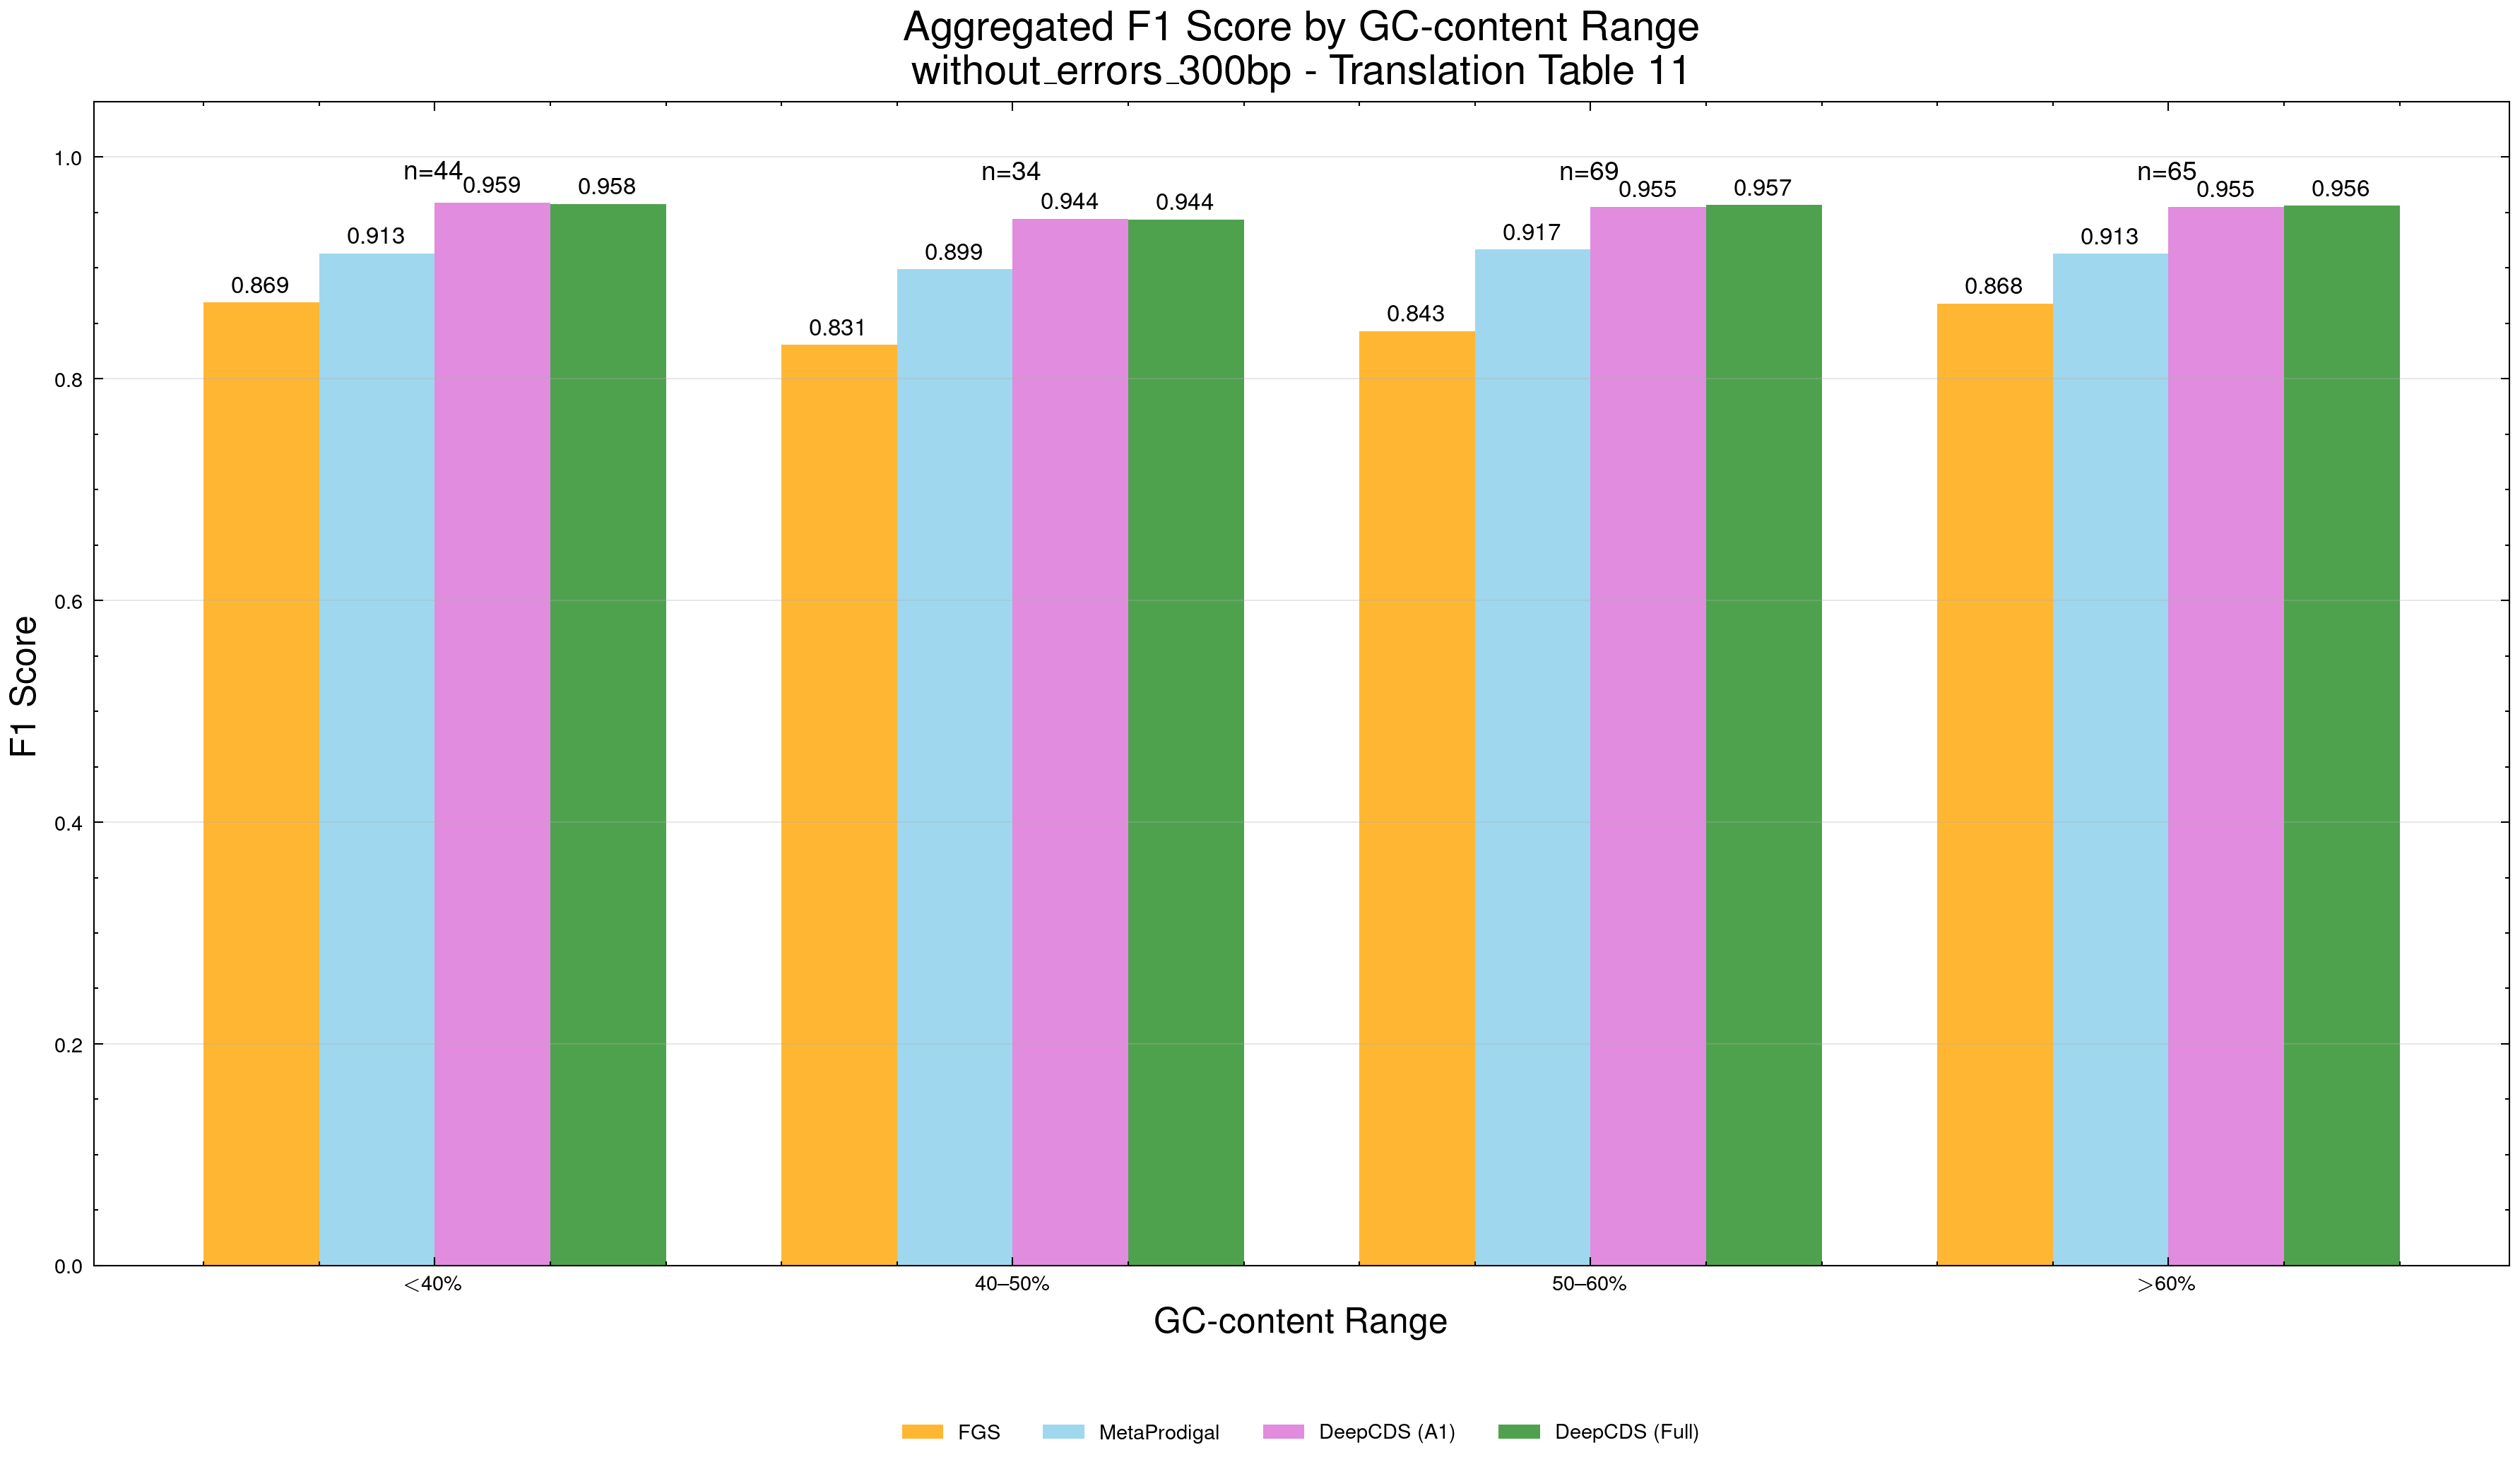

In [498]:
# Plot for Translation Table 11 only (standard bacterial/archaeal code)
tt11_performance_metrics_ordered = reorder_metrics(tt11_performance_metrics, model_order)

for data_type in data_types:
    print("=" * 60)
    print("TRANSLATION TABLE 11 (Standard Bacterial/Archaeal Code)")
    print("=" * 60)
    
    # Boxplots
    plot_metric_by_gc_content_boxplot(tt11_performance_metrics_ordered, all_genomes, 'f1_score', 
                                      f"{data_type} - Translation Table 11",
                                      model_display_names=model_display_names_ordered, colors=custom_colors_ordered)
    
    # Sina plots
    plot_metric_by_gc_content_sina(tt11_performance_metrics_ordered, all_genomes, 'f1_score', 
                                   f"{data_type} - Translation Table 11",
                                   model_display_names=model_display_names_ordered, colors=custom_colors_ordered)
    #plot_metric_by_gc_content_sina(tt11_performance_metrics_ordered, all_genomes, 'recall', 
    #                               f"{data_type} - Translation Table 11",
    #                               model_display_names=model_display_names_ordered, colors=custom_colors_ordered)
    #plot_metric_by_gc_content_sina(tt11_performance_metrics_ordered, all_genomes, 'precision', 
    #                               f"{data_type} - Translation Table 11",
    #                               model_display_names=model_display_names_ordered, colors=custom_colors_ordered)
    
    # Barplots (aggregated)
    plot_metric_by_gc_content_bars(tt11_performance_metrics_ordered, all_genomes, 'f1_score', 
                                   f"{data_type} - Translation Table 11",
                                   model_display_names=model_display_names_ordered, colors=custom_colors_ordered)

In [499]:
wrong_predictions

{'reads_with_fp': ['GCF_000013425.1_simulated_reads_template5829',
  'GCF_000013425.1_simulated_reads_complement88',
  'GCF_000013425.1_simulated_reads_complement9113',
  'GCF_000013425.1_simulated_reads_complement9159',
  'GCF_000013425.1_simulated_reads_template8515',
  'GCF_000013425.1_simulated_reads_template4149',
  'GCF_000013425.1_simulated_reads_complement4797',
  'GCF_000013425.1_simulated_reads_template8158',
  'GCF_000013425.1_simulated_reads_complement4624',
  'GCF_000013425.1_simulated_reads_complement7291',
  'GCF_000013425.1_simulated_reads_template717',
  'GCF_000013425.1_simulated_reads_complement8904',
  'GCF_000013425.1_simulated_reads_complement2983',
  'GCF_000013425.1_simulated_reads_complement5110',
  'GCF_000013425.1_simulated_reads_complement4887',
  'GCF_000013425.1_simulated_reads_template4058',
  'GCF_000013425.1_simulated_reads_template8940',
  'GCF_000013425.1_simulated_reads_complement2395',
  'GCF_000013425.1_simulated_reads_complement4033',
  'GCF_00001

# Track Poor Performing Accessions (F1-score < 0.45)

In [500]:
def find_poor_performing_accessions(performance_metrics_dict, genome_metadata, f1_threshold=0.45):
    """
    Find accession numbers with F1-scores below a specified threshold for each model.
    
    Args:
        performance_metrics_dict (dict): Dictionary with genome accessions as keys and model metrics as values
        genome_metadata (dict): Dictionary with genome metadata (family, gc_content, domain, translation_table)
        f1_threshold (float): F1-score threshold below which performance is considered poor. Default: 0.45
    
    Returns:
        poor_performers (dict): Dictionary with model names as keys and lists of (accession, f1_score, metadata) tuples
    """
    # Get model names from the first genome entry
    first_genome = next(iter(performance_metrics_dict.values()))
    model_names = list(first_genome.keys())
    
    poor_performers = {model: [] for model in model_names}
    
    for accession, metrics in performance_metrics_dict.items():
        metadata = genome_metadata.get(accession, {})
        
        for model in model_names:
            if model in metrics and 'f1_score' in metrics[model]:
                f1_score = metrics[model]['f1_score']
                
                if f1_score < f1_threshold:
                    poor_performers[model].append({
                        'accession': accession,
                        'f1_score': f1_score,
                        'precision': metrics[model].get('precision', None),
                        'recall': metrics[model].get('recall', None),
                        'family': metadata.get('family', 'Unknown'),
                        'gc_content': metadata.get('gc_content', None),
                        'domain': metadata.get('domain', 'Unknown'),
                        'translation_table': metadata.get('translation_table', None)
                    })
    
    # Sort each model's poor performers by F1-score (ascending)
    for model in model_names:
        poor_performers[model] = sorted(poor_performers[model], key=lambda x: x['f1_score'])
    
    return poor_performers


def display_poor_performers(poor_performers, model_display_names=None):
    """
    Display poor performing accessions in a formatted way.
    
    Args:
        poor_performers (dict): Output from find_poor_performing_accessions
        model_display_names (dict, optional): Dictionary mapping model names to display names
    """
    if model_display_names is None:
        model_display_names = {model: model for model in poor_performers.keys()}
    
    print("=" * 100)
    print("ACCESSIONS WITH F1-SCORE < 0.45")
    print("=" * 100)
    
    for model, performers in poor_performers.items():
        display_name = model_display_names.get(model, model)
        print(f"\n{'='*50}")
        print(f"MODEL: {display_name} ({len(performers)} poor performing accessions)")
        print(f"{'='*50}")
        
        if not performers:
            print("  No accessions with F1-score below threshold.")
            continue
        
        for entry in performers:
            print(f"  Accession: {entry['accession']}")
            print(f"    F1: {entry['f1_score']:.3f} | Precision: {entry['precision']:.3f} | Recall: {entry['recall']:.3f}")
            print(f"    Family: {entry['family']} | GC: {entry['gc_content']}% | Domain: {entry['domain']} | TT: {entry['translation_table']}")
            print()


def export_poor_performers_to_df(poor_performers):
    """
    Export poor performing accessions to a DataFrame for further analysis.
    
    Args:
        poor_performers (dict): Output from find_poor_performing_accessions
    
    Returns:
        pd.DataFrame: DataFrame with all poor performing accessions across models
    """
    rows = []
    for model, performers in poor_performers.items():
        for entry in performers:
            row = {'model': model, **entry}
            rows.append(row)
    
    return pd.DataFrame(rows)

In [501]:
# Find and display poor performing accessions (F1-score < 0.45)
poor_performers = find_poor_performing_accessions(
    all_performance_metrics_dict, 
    all_genomes, 
    f1_threshold=0.45
)

# Display the results
display_poor_performers(poor_performers, model_display_names_ordered)

ACCESSIONS WITH F1-SCORE < 0.45

MODEL: FGS (0 poor performing accessions)
  No accessions with F1-score below threshold.

MODEL: MetaProdigal (0 poor performing accessions)
  No accessions with F1-score below threshold.

MODEL: DeepCDS (A1) (0 poor performing accessions)
  No accessions with F1-score below threshold.

MODEL: DeepCDS (Full) (0 poor performing accessions)
  No accessions with F1-score below threshold.


In [502]:
# Export to DataFrame for easier analysis
poor_performers_df = export_poor_performers_to_df(poor_performers)

# Display summary counts per model
print("Summary: Count of poor performing accessions (F1 < 0.45) per model")
print(poor_performers_df.groupby('model').size().rename('count'))
print()

# Show the DataFrame
poor_performers_df

Summary: Count of poor performing accessions (F1 < 0.45) per model


KeyError: 'model'

In [ ]:
# Find accessions that are poor performers across multiple models
accession_model_counts = poor_performers_df.groupby('accession')['model'].count().reset_index()
accession_model_counts.columns = ['accession', 'num_models_poor']

# Merge with metadata to see which accessions struggle across all models
multi_model_poor = accession_model_counts[accession_model_counts['num_models_poor'] > 1].sort_values('num_models_poor', ascending=False)

print(f"Accessions with poor performance (F1 < 0.45) across multiple models:")
print(f"Total: {len(multi_model_poor)} accessions\n")

# Show details for accessions poor across 3+ models
print("Accessions poor across 3+ models:")
for _, row in multi_model_poor[multi_model_poor['num_models_poor'] >= 3].iterrows():
    acc = row['accession']
    metadata = all_genomes.get(acc, {})
    subset = poor_performers_df[poor_performers_df['accession'] == acc][['model', 'f1_score']].set_index('model')
    print(f"\n{acc} - Family: {metadata.get('family', 'Unknown')}, GC: {metadata.get('gc_content', 'N/A')}%")
    print(f"  Poor in {row['num_models_poor']} models:")
    for model, f1_row in subset.iterrows():
        print(f"    {model_display_names_ordered.get(model, model)}: F1={f1_row['f1_score']:.3f}")

Accessions with poor performance (F1 < 0.45) across multiple models:
Total: 3 accessions

Accessions poor across 3+ models:

GCF_000026105.1 - Family: Pseudomonadaceae, GC: 64.2%
  Poor in 4 models:
    FGS: F1=0.044
    MetaProdigal: F1=0.083
    DeepCDS (A1): F1=0.389
    DeepCDS (Full): F1=0.443

GCF_900636915.1 - Family: Pasteurellaceae, GC: 42.3%
  Poor in 4 models:
    FGS: F1=0.060
    MetaProdigal: F1=0.133
    DeepCDS (A1): F1=0.371
    DeepCDS (Full): F1=0.347


In [ ]:
# Extract just the accession numbers per model (for easy access)
poor_accessions_by_model = {
    model: [entry['accession'] for entry in performers] 
    for model, performers in poor_performers.items()
}

# Print summary
print("Poor performing accession lists per model:")
for model, accessions in poor_accessions_by_model.items():
    display_name = model_display_names_ordered.get(model, model)
    print(f"\n{display_name}: {len(accessions)} accessions")
    if accessions:
        print(f"  {accessions}")

Poor performing accession lists per model:

FGS: 3 accessions
  ['GCF_000026105.1', 'GCF_900636915.1', 'GCF_900635955.1']

MetaProdigal: 3 accessions
  ['GCF_000026105.1', 'GCF_900636915.1', 'GCF_900635955.1']

DeepCDS (A1): 2 accessions
  ['GCF_900636915.1', 'GCF_000026105.1']

DeepCDS (Full): 2 accessions
  ['GCF_900636915.1', 'GCF_000026105.1']
